# Quantum Reservoir Computing — Financial Volatility Forecasting

**Team QuantumEdge — GIC 2026 Phase 3 Prototype**

This notebook implements the improved dual-timescale QRC pipeline for financial volatility prediction (S&P 500 / VIX / Oxford-Man).

## Key improvements over the Phase 2 prototype

| Change | Phase 2 | This notebook |
|--------|---------|---------------|
| Input encoding | Single scalar RY broadcast to all qubits | **Multi-feature cyclic encoding**: short reservoir gets (rv_d, log_ret, gk); long reservoir gets (rv_w, rv_m, vix, vix_rv_spread) |
| Dataset | Synthetic (Mackey-Glass, Lorenz) | **Real financial data**: S&P 500 OHLCV, CBOE VIX, Oxford-Man RV |
| Readout features | Pauli + entanglement | Pauli + entanglement + **HMM regime posteriors** |
| Metrics | RMSE only | **RMSE, QLIKE, regime accuracy, Sharpe ratio** |
| Baselines | None | **GARCH, HAR-RV, ESN, LSTM, XGBoost, ARIMA** (from classical-baseline) |
| Ridge conditioning | Tracked implicitly | **Alpha ratio tracked explicitly** as dual vs single stability metric |

**qBraid note:** Upload this notebook and `qrc_financial.py` (companion module) to the same folder, then run with the Python 3 [PennyLane] kernel.

## 0. Package Bootstrap

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy==1.26.4",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "pennylane": "pennylane==0.43.0",
    "yfinance": "yfinance",
    "hmmlearn": "hmmlearn",
}

missing = [pkg for mod, pkg in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing missing packages:", ", ".join(missing))
    get_ipython().run_line_magic("pip", f"install --quiet {' '.join(missing)}")
else:
    print("All required packages already installed.")

All required packages already installed.


## 1. Imports and Configuration

In [2]:
import io
import json
import time
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from hmmlearn.hmm import GaussianHMM
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# ---------------------------------------------------------------------------
# Reservoir configuration
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class ReservoirConfig:
    """Fixed Ising reservoir. feature_cols are assigned cyclically across qubits."""
    name: str
    n_qubits: int
    coupling_j: float
    transverse_h: float
    trotter_depth: int
    feature_cols: tuple

# Features are log-transformed RV quantities. Log-space encoding is critical:
# raw RV spans 4 orders of magnitude so linear MinMaxScaling wastes ~90% of
# the rotation angle range on tail events. Log-space spreads the signal evenly.
SHORT_RESERVOIR = ReservoirConfig(
    name="short-memory",
    n_qubits=9,
    coupling_j=0.3,
    transverse_h=1.0,
    trotter_depth=2,
    feature_cols=("log_rv_d", "log_ret", "log_gk"),
)
LONG_RESERVOIR = ReservoirConfig(
    name="long-memory",
    n_qubits=9,
    coupling_j=1.2,
    transverse_h=0.4,
    trotter_depth=6,
    feature_cols=("log_rv_w", "log_rv_m", "vix", "vix_rv_spread"),
)

N_QUBITS       = 9
N_ENT          = 8
RIDGE_ALPHAS   = np.logspace(-6, 6, 25)
ANGLE_RANGE    = (-np.pi / 2, np.pi / 2)
TRAIN_FRAC     = 0.80
RESULTS_DIR    = Path("qrc_financial_results")
RESULTS_DIR.mkdir(exist_ok=True)

# Device selection
DEVICE_NAME = "default.qubit"
for _dev in ("lightning.qubit", "default.qubit"):
    try:
        qml.device(_dev, wires=1)
        DEVICE_NAME = _dev
        break
    except Exception:
        pass

plt.rcParams.update({"figure.figsize": (13, 4), "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})

print("PennyLane:", qml.__version__)
print("Device:   ", DEVICE_NAME)
print("\nReservoir configs:")
for cfg in (SHORT_RESERVOIR, LONG_RESERVOIR):
    print(f"  {cfg.name:<13} n={cfg.n_qubits}, J={cfg.coupling_j}, "
          f"h={cfg.transverse_h}, p={cfg.trotter_depth}")
    print(f"  {'':13} features={cfg.feature_cols}")

PennyLane: 0.43.0
Device:    default.qubit

Reservoir configs:
  short-memory  n=9, J=0.3, h=1.0, p=2
                features=('log_rv_d', 'log_ret', 'log_gk')
  long-memory   n=9, J=1.2, h=0.4, p=6
                features=('log_rv_w', 'log_rv_m', 'vix', 'vix_rv_spread')


## 2. Financial Data Loading

Downloads S&P 500 OHLCV (yfinance), CBOE VIX, and Oxford-Man realized volatility (with Garman-Klass fallback). Results are cached to `data/raw/` to avoid repeated downloads.

In [3]:
import urllib.request
import yfinance as yf

RAW = Path("data/raw")
RAW.mkdir(parents=True, exist_ok=True)

START, END = "2010-01-01", "2025-12-31"
OXFORD_MAN_URL = "https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip"


def _load_sp500():
    path = RAW / "sp500_ohlcv.csv"
    if path.exists():
        return pd.read_csv(path, index_col=0, parse_dates=True)
    print("[data] SP500: downloading...")
    df = yf.download("^GSPC", start=START, end=END, auto_adjust=True,
                     progress=False, multi_level_index=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].ffill(limit=2).dropna()
    df.index.name = "Date"
    df.to_csv(path)
    print(f"[data] SP500: {len(df)} rows saved.")
    return df


def _load_vix(idx):
    path = RAW / "vix.csv"
    if path.exists():
        return pd.read_csv(path, index_col=0, parse_dates=True).squeeze().reindex(idx).ffill()
    print("[data] VIX: downloading...")
    df = yf.download("^VIX", start=START, end=END, auto_adjust=True,
                     progress=False, multi_level_index=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    s = df["Close"].rename("VIX")
    s.index.name = "Date"
    s.to_csv(path)
    return s.reindex(idx).ffill()


def _try_oxford_man():
    try:
        print("[data] Oxford-Man: downloading...")
        with urllib.request.urlopen(OXFORD_MAN_URL, timeout=30) as r:
            raw_bytes = r.read()
        with zipfile.ZipFile(io.BytesIO(raw_bytes)) as z:
            csv_name = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(csv_name) as f:
                df = pd.read_csv(f, index_col=0, parse_dates=True, low_memory=False)
        sym_col = next((c for c in df.columns if c.lower() in ("symbol", "sym")), None)
        spx = df[df[sym_col] == ".SPX"] if sym_col else df
        spx.index = pd.to_datetime(spx.index)
        spx = spx.sort_index()
        spx = spx[(spx.index >= START) & (spx.index <= END)]
        rv_col = next((c for c in spx.columns if "rv5" in c.lower()), None)
        if rv_col is None:
            return None
        return spx[[rv_col]].rename(columns={rv_col: "rv5"})
    except Exception as e:
        print(f"[data] Oxford-Man failed: {e}")
        return None


def _gk_rv(sp500):
    h = np.log(sp500["High"] / sp500["Open"])
    l = np.log(sp500["Low"] / sp500["Open"])
    c = np.log(sp500["Close"] / sp500["Open"])
    return (0.5 * (h - l) ** 2 - (2 * np.log(2) - 1) * c ** 2).clip(lower=0).rename("rv5")


def _load_oxford_man(sp500):
    path = RAW / "oxford_man_rv.csv"
    src_path = RAW / "oxford_man_source.txt"
    if path.exists():
        source = src_path.read_text().strip() if src_path.exists() else "cache"
        return pd.read_csv(path, index_col=0, parse_dates=True), source
    om = _try_oxford_man()
    if om is not None:
        om.to_csv(path)
        src_path.write_text("oxford-man-primary")
        return om, "oxford-man-primary"
    print("[data] Using Garman-Klass fallback.")
    gk = _gk_rv(sp500).to_frame()
    gk.to_csv(path)
    src_path.write_text("garman-klass-fallback")
    return gk, "garman-klass-fallback"


sp500    = _load_sp500()
vix      = _load_vix(sp500.index)
oxford_man, rv_source = _load_oxford_man(sp500)

print(f"\nSP500:      {len(sp500)} rows  ({sp500.index[0].date()} → {sp500.index[-1].date()})")
print(f"VIX:        {vix.notna().sum()} valid rows")
print(f"Oxford-Man: {len(oxford_man)} rows  (source={rv_source})")


SP500:      4023 rows  (2010-01-04 → 2025-12-30)
VIX:        4023 valid rows
Oxford-Man: 4023 rows  (source=garman-klass-fallback)


## 3. Feature Engineering

HAR-style decomposition of realized variance into daily (rv_d), weekly (rv_w = 5-day mean), and monthly (rv_m = 22-day mean) components. These map directly to the two-reservoir design: fast features → short reservoir, slow features → long reservoir.

In [4]:
def build_financial_features(sp500, vix, oxford_man):
    df = sp500[["Open", "High", "Low", "Close"]].copy()
    df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))

    rv = (oxford_man["rv5"].reindex(df.index).ffill().bfill()
          if "rv5" in oxford_man.columns
          else _gk_rv(sp500).reindex(df.index))
    df["rv"] = rv

    # Garman-Klass (log-space)
    h = np.log(df["High"] / df["Open"])
    l = np.log(df["Low"] / df["Open"])
    c = np.log(df["Close"] / df["Open"])
    df["gk"] = (0.5 * (h - l) ** 2 - (2 * np.log(2) - 1) * c ** 2).clip(lower=0)

    # HAR components in raw space (for reference)
    df["rv_d"] = df["rv"]
    df["rv_w"] = df["rv"].rolling(5,  min_periods=5).mean()
    df["rv_m"] = df["rv"].rolling(22, min_periods=22).mean()

    # Log-space RV features — RV spans 4 orders of magnitude; linear encoding
    # wastes 90% of the angle range on tail events. Log-space fixes this.
    df["log_rv_d"] = np.log(df["rv_d"].clip(lower=1e-10))
    df["log_rv_w"] = np.log(df["rv_w"].clip(lower=1e-10))
    df["log_rv_m"] = np.log(df["rv_m"].clip(lower=1e-10))
    df["log_gk"]   = np.log(df["gk"].clip(lower=1e-10))

    # VIX features (already in roughly linear scale — no log needed)
    df["vix"] = vix.reindex(df.index).ffill()
    df["vix_rv_spread"] = (df["vix"] / 100) ** 2 / 252 - df["rv"]

    # Targets: raw RV for RMSE/QLIKE, log RV for angle-space prediction
    df["target_rv"]     = df["rv"].shift(-1)
    df["target_log_rv"] = np.log(df["rv"].shift(-1).clip(lower=1e-10))

    return df.dropna()


df = build_financial_features(sp500, vix, oxford_man)
n_total = len(df)
n_train = int(n_total * TRAIN_FRAC)
n_test  = n_total - n_train

df_train = df.iloc[:n_train]
df_test  = df.iloc[n_train:]

# Log-space feature sets per reservoir
SHORT_COLS = ["log_rv_d", "log_ret", "log_gk"]    # fast daily signals
LONG_COLS  = ["log_rv_w", "log_rv_m", "vix", "vix_rv_spread"]  # slow multi-day signals

print(f"Financial dataset: {n_total} rows  (train={n_train}, test={n_test})")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"\nShort reservoir features (log-space): {SHORT_COLS}")
print(f"Long  reservoir features (log-space): {LONG_COLS}")
print()
print(df[SHORT_COLS + LONG_COLS + ["target_rv"]].describe().T[["mean", "std", "min", "max"]])

Financial dataset: 4001 rows  (train=3200, test=801)
Date range: 2010-02-03 → 2025-12-29

Short reservoir features (log-space): ['log_rv_d', 'log_ret', 'log_gk']
Long  reservoir features (log-space): ['log_rv_w', 'log_rv_m', 'vix', 'vix_rv_spread']

                    mean       std           min        max
log_rv_d      -10.429685  1.169825 -1.399915e+01  -5.579545
log_ret         0.000458  0.010947 -1.276522e-01   0.090895
log_gk        -10.429685  1.169825 -1.399915e+01  -5.579545
log_rv_w      -10.215489  0.966794 -1.301725e+01  -6.132617
log_rv_m      -10.082575  0.845497 -1.221211e+01  -6.851909
vix            18.402359  6.886963  9.140000e+00  82.690002
vix_rv_spread   0.000089  0.000122 -3.347363e-03   0.001257
target_rv       0.000064  0.000152  8.322392e-07   0.003774


## 4. HMM Regime Fitting

3-state Gaussian HMM on log(RV) — fit on training data only. The posteriors P(regime | data) are appended to the QRC feature vector in the regime-conditioned readout variant.

HMM thresholds (RV):  low/med=4.68e-05  med/high=7.85e-05
Train regime counts:  Low=1963  Med=619  High=618
Regime posteriors shape: (4001, 3)


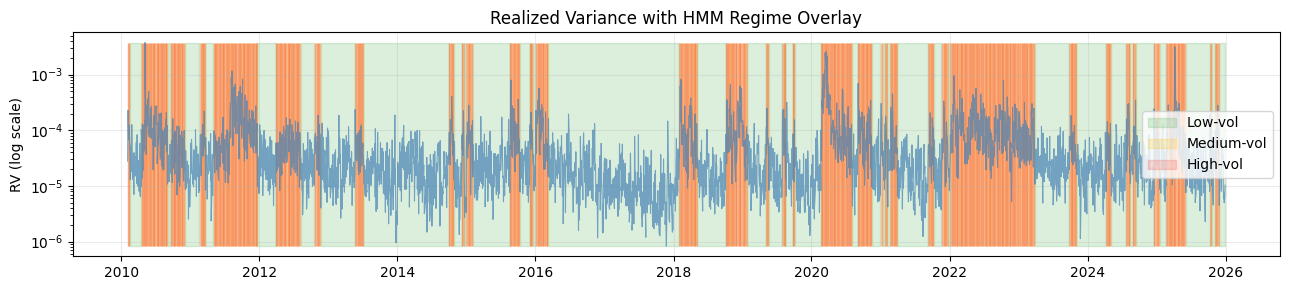

In [5]:
REGIME_NAMES = {0: "Low-vol", 1: "Medium-vol", 2: "High-vol"}
REGIME_COLORS = {0: "#4CAF50", 1: "#FFC107", 2: "#F44336"}

# Fit HMM on training log(RV)
log_rv_train = np.log(df_train["rv"].values + 1e-10).reshape(-1, 1)
hmm_model = GaussianHMM(n_components=3, covariance_type="full",
                         n_iter=200, random_state=SEED)
hmm_model.fit(log_rv_train)

# Sort HMM states by ascending mean → Low=0, Medium=1, High=2
means = hmm_model.means_.flatten()
sorted_states = np.argsort(means)
state_map = {int(sorted_states[i]): i for i in range(3)}

# RV decision boundaries (midpoints between adjacent state means)
sorted_means_rv = np.exp(np.sort(means))
thresholds = (float((sorted_means_rv[0] + sorted_means_rv[1]) / 2),
              float((sorted_means_rv[1] + sorted_means_rv[2]) / 2))

def predict_regimes(rv_series):
    log_rv = np.log(np.asarray(rv_series, dtype=float) + 1e-10).reshape(-1, 1)
    raw = hmm_model.predict(log_rv)
    return np.array([state_map[int(s)] for s in raw])

def causal_regime_posteriors(rv_series):
    """Causal forward filter: P(state_t | obs[0..t]) — no look-ahead bias."""
    from scipy.stats import norm as gauss_norm
    log_obs = np.log(np.asarray(rv_series, dtype=float) + 1e-10)
    n = len(log_obs)
    K = hmm_model.n_components
    B = np.zeros((n, K))
    for k in range(K):
        mu    = hmm_model.means_[k, 0]
        sigma = np.sqrt(hmm_model.covars_[k, 0, 0])
        B[:, k] = gauss_norm.pdf(log_obs, mu, sigma)
    alpha = np.zeros((n, K))
    alpha[0] = hmm_model.startprob_ * B[0]
    s = alpha[0].sum(); alpha[0] /= s if s > 0 else 1.0
    for t in range(1, n):
        alpha[t] = (alpha[t - 1] @ hmm_model.transmat_) * B[t]
        s = alpha[t].sum(); alpha[t] /= s if s > 0 else 1.0
    out = np.zeros_like(alpha)
    for raw_s, sorted_s in state_map.items():
        out[:, sorted_s] = alpha[:, raw_s]
    return out

# Causal posteriors — forward algorithm only, no look-ahead
all_posteriors = causal_regime_posteriors(df["rv"].values)
train_regimes  = predict_regimes(df_train["rv"].values)
test_regimes   = predict_regimes(df_test["rv"].values)

regime_counts = {r: int((train_regimes == r).sum()) for r in range(3)}
print(f"HMM thresholds (RV):  low/med={thresholds[0]:.2e}  med/high={thresholds[1]:.2e}")
print(f"Train regime counts:  Low={regime_counts[0]}  Med={regime_counts[1]}  High={regime_counts[2]}")
print(f"Regime posteriors shape: {all_posteriors.shape}")

# Quick regime overlay plot
fig, ax = plt.subplots(figsize=(13, 3))
ax.semilogy(df.index, df["rv"], color="steelblue", lw=0.8, alpha=0.7)
for r, color in REGIME_COLORS.items():
    mask = np.append(predict_regimes(df["rv"].values) == r, False)
    ax.fill_between(df.index, df["rv"].min(), df["rv"].max(),
                    where=mask[:len(df.index)], alpha=0.2, color=color,
                    label=REGIME_NAMES[r])
ax.set_title("Realized Variance with HMM Regime Overlay")
ax.set_ylabel("RV (log scale)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hmm_regime_overlay.png", dpi=150)
plt.show()

## 5. Multi-Feature Angle Encoding

Each feature column gets its own MinMaxScaler, fit on training data only. The encoders map features to rotation angles in [-π/2, π/2]. This makes the HAR decomposition structurally explicit:

```
Short reservoir (9 qubits, p=2):    Long reservoir (9 qubits, p=6):
  qubit 0  ← RY(rv_d)                  qubit 0  ← RY(rv_w)
  qubit 1  ← RY(log_ret)               qubit 1  ← RY(rv_m)
  qubit 2  ← RY(gk)                    qubit 2  ← RY(vix)
  qubit 3  ← RY(rv_d)       [cyclic]   qubit 3  ← RY(vix_rv_spread)  [cyclic]
  qubit 4  ← RY(log_ret)               qubit 4  ← RY(rv_w)
  ...                                   ...
```

Each feature gets 3 injection points (9 qubits / 3 features), repeated at every Trotter layer, giving encoding density of O(depth × qubits / n_features).

In [6]:
def fit_feature_encoder(df_train, feature_cols):
    """Fit per-feature MinMaxScaler on training data. Returns dict of scalers."""
    scalers = {}
    for col in feature_cols:
        s = MinMaxScaler(feature_range=ANGLE_RANGE)
        s.fit(df_train[[col]])
        scalers[col] = s
    return scalers


def encode_series(df, feature_cols, scalers):
    """Encode DataFrame to angle matrix of shape (T, n_features)."""
    out = np.zeros((len(df), len(feature_cols)))
    for j, col in enumerate(feature_cols):
        vals = scalers[col].transform(df[[col]]).ravel()
        out[:, j] = np.clip(vals, *ANGLE_RANGE)
    return out


short_scalers = fit_feature_encoder(df_train, SHORT_COLS)
long_scalers  = fit_feature_encoder(df_train, LONG_COLS)

short_angles = encode_series(df, SHORT_COLS, short_scalers)  # (T, 3)
long_angles  = encode_series(df, LONG_COLS,  long_scalers)   # (T, 4)

# The first short feature is log_rv_d. The target angle is also log_rv_d at t+1.
# To invert predictions: angle → log_rv (inverse_transform) → rv (exp).
log_rv_d_scaler = short_scalers["log_rv_d"]

def angle_to_rv(angles):
    """Convert log_rv_d angle predictions back to raw RV space."""
    clipped = np.clip(angles, *ANGLE_RANGE)
    log_rv = log_rv_d_scaler.inverse_transform(clipped.reshape(-1, 1)).ravel()
    return np.exp(log_rv)


# Verify shapes and ranges
print("Short angle matrix:", short_angles.shape,
      f"  range [{short_angles.min():.3f}, {short_angles.max():.3f}]")
print("Long  angle matrix:", long_angles.shape,
      f"  range [{long_angles.min():.3f}, {long_angles.max():.3f}]")
print()
print("Per-feature angle ranges (train slice) — should fill [-π/2, π/2] well:")
for j, col in enumerate(SHORT_COLS):
    a = short_angles[:n_train, j]
    print(f"  short/{col:<15} [{a.min():.3f}, {a.max():.3f}]  std={a.std():.3f}")
for j, col in enumerate(LONG_COLS):
    a = long_angles[:n_train, j]
    print(f"  long/{col:<16} [{a.min():.3f}, {a.max():.3f}]  std={a.std():.3f}")

Short angle matrix: (4001, 3)   range [-1.571, 1.571]
Long  angle matrix: (4001, 4)   range [-1.571, 1.571]

Per-feature angle ranges (train slice) — should fill [-π/2, π/2] well:
  short/log_rv_d        [-1.571, 1.571]  std=0.450
  short/log_ret         [-1.571, 1.571]  std=0.162
  short/log_gk          [-1.571, 1.571]  std=0.450
  long/log_rv_w         [-1.571, 1.571]  std=0.458
  long/log_rv_m         [-1.571, 1.571]  std=0.515
  long/vix              [-1.571, 1.571]  std=0.314
  long/vix_rv_spread    [-1.571, 1.571]  std=0.084


## 6. Multi-Feature Quantum Reservoir Circuits

Key change from Phase 2: `feature_angles[wire % n_features]` replaces the single scalar broadcast. Each qubit now receives a distinct financial signal at each Trotter layer injection.

In [7]:
def make_qnode(config):
    """Statevector QNode with multi-feature cyclic encoding."""
    dev = qml.device(DEVICE_NAME, wires=config.n_qubits)
    n_feats = len(config.feature_cols)

    @qml.qnode(dev, interface="numpy")
    def reservoir(feature_angles):
        for _ in range(config.trotter_depth):
            for wire in range(config.n_qubits):
                qml.RY(float(feature_angles[wire % n_feats]), wires=wire)
            for wire in range(config.n_qubits - 1):
                qml.IsingZZ(2.0 * config.coupling_j, wires=[wire, wire + 1])
            for wire in range(config.n_qubits):
                qml.RX(2.0 * config.transverse_h, wires=wire)
        return qml.state()

    return reservoir


def pauli_features(sv, n_qubits):
    probs = np.abs(np.asarray(sv, dtype=np.complex128)) ** 2
    tensor = probs.reshape((2,) * n_qubits)
    single_z = []
    for w in range(n_qubits):
        m = tensor.sum(axis=tuple(a for a in range(n_qubits) if a != w))
        single_z.append(float(m[0] - m[1]))
    pair_zz = []
    for w in range(n_qubits - 1):
        keep = (w, w + 1)
        m = tensor.sum(axis=tuple(a for a in range(n_qubits) if a not in keep))
        pair_zz.append(float(m[0, 0] + m[1, 1] - m[0, 1] - m[1, 0]))
    return np.array(single_z + pair_zz, dtype=float)


def entanglement_features(sv, n_qubits, n_keep=N_ENT):
    n_left  = n_qubits // 2
    n_right = n_qubits - n_left
    psi = np.asarray(sv, dtype=np.complex128).reshape(2 ** n_left, 2 ** n_right)
    rho = psi @ psi.conj().T
    eigvals = np.linalg.eigvalsh(rho).real
    eigvals = np.sort(np.clip(eigvals, 1e-12, 1.0))[::-1]
    energies = -np.log(eigvals)
    if len(energies) < n_keep:
        energies = np.pad(energies, (0, n_keep - len(energies)), constant_values=0.0)
    return energies[:n_keep]


short_qnode = make_qnode(SHORT_RESERVOIR)
long_qnode  = make_qnode(LONG_RESERVOIR)

# Sanity check: feature sizes
ex_sv   = short_qnode(short_angles[0])
ex_pau  = pauli_features(ex_sv, N_QUBITS)
ex_ent  = entanglement_features(ex_sv, N_QUBITS)

n_pauli = len(ex_pau)
print(f"Statevector length:           {len(ex_sv)}")
print(f"Pauli features per reservoir: {n_pauli}  (= 2n-1 = {2*N_QUBITS-1})")
print(f"Entanglement features/res:    {len(ex_ent)}")
print()
print("Readout feature vector sizes:")
print(f"  dual_pauli:       {2*n_pauli + 1:3d}  (2×{n_pauli} Pauli + 1 feedback)")
print(f"  dual_ent:         {2*(n_pauli+N_ENT)+1:3d}  (2×{n_pauli+N_ENT} Pauli+Ent + 1 feedback)")
print(f"  dual_ent_regime:  {2*(n_pauli+N_ENT)+1+3:3d}  (+ 3 HMM posteriors)")
print(f"  single_long_ent:  {n_pauli+N_ENT+1:3d}  (ablation)")

Statevector length:           512
Pauli features per reservoir: 17  (= 2n-1 = 17)
Entanglement features/res:    8

Readout feature vector sizes:
  dual_pauli:        35  (2×17 Pauli + 1 feedback)
  dual_ent:          51  (2×25 Pauli+Ent + 1 feedback)
  dual_ent_regime:   54  (+ 3 HMM posteriors)
  single_long_ent:   26  (ablation)


## 7. Reservoir Feature Extraction

Drive both reservoirs over the full financial time series. For each time step t:
- Short reservoir receives `[rv_d_t, log_ret_t, gk_t]` → Pauli + entanglement features
- Long reservoir receives `[rv_w_t, rv_m_t, vix_t, vix_rv_spread_t]` → Pauli + entanglement features
- HMM regime posterior `[P(Low), P(Med), P(High)]` appended for regime-conditioned variant
- Target: next-step rv_d angle (inverted to RV space for final metrics)

Expected wall time on `lightning.qubit`: ~30–60s for ~3000 financial steps.

In [8]:
def extract_features(short_angles_full, long_angles_full, posteriors_full,
                     short_node, long_node, n_qubits, n_ent, label="", progress_every=300):
    T = short_angles_full.shape[0] - 1
    dp_rows, de_rows, der_rows, sl_rows = [], [], [], []
    t0 = time.perf_counter()

    for t in range(T):
        sv_s = short_node(short_angles_full[t])
        sv_l = long_node(long_angles_full[t])

        pau_s = pauli_features(sv_s, n_qubits)
        pau_l = pauli_features(sv_l, n_qubits)
        ent_s = entanglement_features(sv_s, n_qubits, n_ent)
        ent_l = entanglement_features(sv_l, n_qubits, n_ent)

        prev_rv = np.array([float(short_angles_full[t, 0])])  # rv_d feedback
        regime  = posteriors_full[t]

        dp_rows.append(np.concatenate([pau_s, pau_l, prev_rv]))
        de_rows.append(np.concatenate([pau_s, pau_l, ent_s, ent_l, prev_rv]))
        der_rows.append(np.concatenate([pau_s, pau_l, ent_s, ent_l, prev_rv, regime]))
        sl_rows.append(np.concatenate([pau_l, ent_l, prev_rv]))

        if progress_every and ((t + 1) % progress_every == 0 or t + 1 == T):
            print(f"{label:<12} {t+1:5d}/{T}  {time.perf_counter()-t0:6.1f}s")

    target_angle = short_angles_full[1:, 0]  # next-step rv_d (normalised)

    return {
        "dual_pauli":      np.vstack(dp_rows),
        "dual_ent":        np.vstack(de_rows),
        "dual_ent_regime": np.vstack(der_rows),
        "single_long_ent": np.vstack(sl_rows),
        "target_angle":    target_angle,
    }


print("Starting reservoir feature extraction...")
t_extract_start = time.perf_counter()

feat = extract_features(
    short_angles, long_angles, all_posteriors,
    short_qnode, long_qnode, N_QUBITS, N_ENT,
    label="Financial",
)

extract_time = time.perf_counter() - t_extract_start
print(f"\nExtraction complete: {extract_time:.1f}s total ({extract_time/len(feat['target_angle'])*1000:.1f}ms/step)")
print()
print("Feature matrix shapes:")
for k, v in feat.items():
    if k != "target_angle":
        print(f"  {k:<20} {v.shape}")
print(f"  {'target_angle':<20} {feat['target_angle'].shape}")

# Save features so ridge can be refit offline without re-running QRC
np.savez_compressed(RESULTS_DIR / "financial_qrc_features.npz", **feat)
print(f"\nFeatures saved to {RESULTS_DIR / 'financial_qrc_features.npz'}")

Starting reservoir feature extraction...


Financial      300/4000     2.9s


Financial      600/4000     5.8s


Financial      900/4000     8.7s


Financial     1200/4000    11.6s


...

Financial     3000/4000    28.9s


Financial     3300/4000    31.7s


Financial     3600/4000    34.7s


Financial     3900/4000    37.5s


Financial     4000/4000    38.4s

Extraction complete: 38.4s total (9.6ms/step)

Feature matrix shapes:
  dual_pauli           (4000, 35)
  dual_ent             (4000, 51)
  dual_ent_regime      (4000, 54)
  single_long_ent      (4000, 26)
  target_angle         (4000,)

Features saved to qrc_financial_results/financial_qrc_features.npz


## 8. Readout Training

Five readout variants trained on the same feature matrices:

| Variant | Features | Purpose |
|---------|----------|---------|
| `dual_pauli` | 35 | Ablation: no entanglement |
| `dual_ent` | 51 | Proposed: Pauli + entanglement |
| `dual_ent_regime` | 54 | **Improved**: + HMM regime posteriors |
| `single_long_ent` | 26 | Ablation: single reservoir |
| `regime_conditioned` | 51 | **Improved**: per-regime Ridge + soft blend |

In [9]:
# Align n_train/n_test to the feature matrices (which have one fewer row due to targeting)
T_feat   = len(feat["target_angle"])
n_tr     = int(T_feat * TRAIN_FRAC)
n_te     = T_feat - n_tr

# Training regime labels and test posteriors for regime-conditioned readout
train_regimes_feat = predict_regimes(df["rv"].values[:n_tr])
test_posteriors    = all_posteriors[n_tr:n_tr + n_te]


def fit_readout(X, y, n_tr, n_te):
    model = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    model.fit(X[:n_tr], y[:n_tr])
    y_pred = model.predict(X[n_tr:n_tr + n_te])
    y_test = y[n_tr:n_tr + n_te]
    rmse   = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    alpha  = float(model.named_steps["ridgecv"].alpha_)
    return {"y_pred": y_pred, "y_test": y_test, "rmse_angle": rmse, "alpha": alpha, "model": model}


class RegimeReadout:
    """Soft-blended per-regime Ridge readouts."""
    def __init__(self):
        self.models_ = {}

    def fit(self, X, y, regime_labels):
        global_m = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
        global_m.fit(X, y)
        for r in range(3):
            mask = regime_labels == r
            if mask.sum() < 10:
                self.models_[r] = global_m
            else:
                m = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
                m.fit(X[mask], y[mask])
                self.models_[r] = m
        return self

    def predict(self, X, posteriors):
        preds = np.column_stack([self.models_[r].predict(X) for r in range(3)])
        return (preds * posteriors).sum(axis=1)



def fit_qlike_readout(X, y, n_tr, n_te):
    """Linear readout trained by minimising QLIKE loss directly (L-BFGS-B).
    
    Replaces Ridge (L2 loss) with the evaluation criterion, so training and
    evaluation objectives are aligned. Lambda tuned on last 20% of training data.
    """
    from scipy.optimize import minimize as sp_minimize

    sc = StandardScaler()
    X_tr = sc.fit_transform(X[:n_tr])
    X_te = sc.transform(X[n_tr:n_tr + n_te])
    y_tr = y[:n_tr]
    y_te = y[n_tr:n_tr + n_te]

    # d(log_rv) / d(angle) from MinMaxScaler
    C = 1.0 / float(log_rv_d_scaler.scale_[0])

    def rv_from_angles(a):
        """angle vector → RV vector (no clip for gradient, clip only for final output)."""
        log_rv = log_rv_d_scaler.inverse_transform(a.reshape(-1, 1)).ravel()
        return np.exp(log_rv)

    def loss_and_grad(w, X_aug, y_rv, lam):
        a = X_aug @ w
        yp = np.maximum(rv_from_angles(a), 1e-12)
        ratio = y_rv / yp
        loss = float(np.mean(ratio - np.log(ratio) - 1)) + lam * float(np.dot(w[:-1], w[:-1]))
        err = 1.0 - ratio                          # (1 - yt/yp), shape (n,)
        grad = C * (X_aug.T @ err) / len(y_rv)    # QLIKE gradient
        grad[:-1] += 2.0 * lam * w[:-1]           # L2 on weights, not bias
        return loss, grad

    # Validation split: last 20% of training data
    n_val = max(50, int(n_tr * 0.20))
    n_fit = n_tr - n_val
    X_fit = X_tr[:n_fit];  X_aug_fit = np.c_[X_fit, np.ones(n_fit)]
    X_val = X_tr[n_fit:];  X_aug_val = np.c_[X_val, np.ones(n_val)]
    y_rv_fit = np.exp(log_rv_d_scaler.inverse_transform(y_tr[:n_fit].reshape(-1,1)).ravel())
    y_rv_val = np.exp(log_rv_d_scaler.inverse_transform(y_tr[n_fit:].reshape(-1,1)).ravel())

    # Ridge warm-start (in angle space)
    w0_fit  = np.append(RidgeCV(alphas=RIDGE_ALPHAS).fit(X_fit, y_tr[:n_fit]).coef_,
                        RidgeCV(alphas=RIDGE_ALPHAS).fit(X_fit, y_tr[:n_fit]).intercept_)
    w0_full = np.append(RidgeCV(alphas=RIDGE_ALPHAS).fit(X_tr, y_tr).coef_,
                        RidgeCV(alphas=RIDGE_ALPHAS).fit(X_tr, y_tr).intercept_)

    best_lam, best_val_qlike = 1e-4, np.inf
    for lam in [1e-5, 1e-4, 1e-3, 0.01, 0.1]:
        res = sp_minimize(loss_and_grad, w0_fit,
                          args=(X_aug_fit, y_rv_fit, lam),
                          method='L-BFGS-B', jac=True,
                          options={'maxiter': 500, 'ftol': 1e-10, 'gtol': 1e-7})
        yp_val = np.maximum(rv_from_angles(X_aug_val @ res.x), 1e-12)
        r = y_rv_val / yp_val
        vq = float(np.mean(r - np.log(r) - 1))
        if vq < best_val_qlike:
            best_val_qlike, best_lam = vq, lam

    # Final fit on full training data
    X_aug_tr = np.c_[X_tr, np.ones(n_tr)]
    y_rv_tr  = np.exp(log_rv_d_scaler.inverse_transform(y_tr.reshape(-1,1)).ravel())
    res_full = sp_minimize(loss_and_grad, w0_full,
                           args=(X_aug_tr, y_rv_tr, best_lam),
                           method='L-BFGS-B', jac=True,
                           options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8})
    w_opt = res_full.x

    X_aug_te = np.c_[X_te, np.ones(n_te)]
    y_pred   = X_aug_te @ w_opt
    rmse     = float(np.sqrt(np.mean((y_te - y_pred)**2)))

    return {"y_pred": y_pred, "y_test": y_te, "rmse_angle": rmse,
            "alpha": best_lam, "model": None}


y = feat["target_angle"]
readouts = {}

for key in ("dual_pauli", "dual_ent", "dual_ent_regime", "single_long_ent"):
    readouts[key] = fit_readout(feat[key], y, n_tr, n_te)

# Regime-conditioned (soft-blend) readout
rc = RegimeReadout()
rc.fit(feat["dual_ent"][:n_tr], y[:n_tr], train_regimes_feat)
y_pred_rc = rc.predict(feat["dual_ent"][n_tr:n_tr+n_te], test_posteriors)
y_test    = y[n_tr:n_tr+n_te]
readouts["regime_conditioned"] = {
    "y_pred": y_pred_rc, "y_test": y_test,
    "rmse_angle": float(np.sqrt(mean_squared_error(y_test, y_pred_rc))),
    "alpha": None, "model": rc,
}

for key in ("dual_ent_qlike", "dual_ent_regime_qlike"):
    feat_key = key.replace("_qlike", "")
    readouts[key] = fit_qlike_readout(feat[feat_key], y, n_tr, n_te)

print("Readout training complete.")
print(f"  Train: {n_tr} steps   Test: {n_te} steps")
print()
print(f"{'Variant':<22} {'RMSE (angle)':>13}  {'Ridge α':>10}")
print("-" * 50)
for name, r in readouts.items():
    alpha_str = f"{r['alpha']:.2e}" if r["alpha"] is not None else "  n/a (blend)"
    print(f"  {name:<20} {r['rmse_angle']:>13.6f}  {alpha_str:>10}")

Readout training complete.
  Train: 3200 steps   Test: 800 steps

Variant                 RMSE (angle)     Ridge α
--------------------------------------------------
  dual_pauli                0.283338    3.16e+00
  dual_ent                  0.282160    3.16e+00
  dual_ent_regime           0.265598    3.16e+00
  single_long_ent           0.287117    3.16e+00
  regime_conditioned        0.268784    n/a (blend)


## 9. Financial Metrics

Predictions are inverted from angle space back to RV space, then evaluated with:
- **RMSE** — point forecast accuracy
- **QLIKE** — Patton (2011) loss, scale-invariant and appropriate for strictly positive variance forecasts
- **Regime accuracy** — fraction of test days correctly classified into Low/Med/High-vol regime
- **Sharpe ratio** — annualised Sharpe of a vol-timing strategy: full position in Low, half in Med, cash in High

In [10]:
def qlike(y_true, y_pred):
    eps = 1e-10
    yt = np.maximum(y_true, eps)
    yp = np.maximum(y_pred, eps)
    ratio = yt / yp
    return float(np.mean(ratio - np.log(ratio) - 1.0))


def classify_by_threshold(rv_pred, thresholds):
    low_t, high_t = thresholds
    out = np.zeros(len(rv_pred), dtype=int)
    out[rv_pred >= low_t] = 1
    out[rv_pred >= high_t] = 2
    return out


def vol_timing_sharpe(pred_rv, test_log_returns, thresholds, trading_days=252):
    """Position: 1.0 (Low), 0.5 (Med), 0.0 (High). pred[t] → position set at t → earns ret[t+1]."""
    n = min(len(pred_rv), len(test_log_returns)) - 1
    if n <= 0:
        return 0.0
    regimes = classify_by_threshold(pred_rv[:n], thresholds)
    positions = np.where(regimes == 0, 1.0, np.where(regimes == 1, 0.5, 0.0))
    strat_returns = positions * test_log_returns[1:n+1]
    std = strat_returns.std()
    return float(strat_returns.mean() / std * np.sqrt(trading_days)) if std > 0 else 0.0


# Ground truth aligned to feature matrix test slice (see alignment note in Section 9 header)
y_true_rv         = df["target_rv"].values[n_tr:n_tr + n_te]
test_returns      = df["log_ret"].values[n_tr:n_tr + n_te]
true_test_regimes = predict_regimes(y_true_rv)

bnh_returns = test_returns[1:]
bnh_sharpe  = float(bnh_returns.mean() / bnh_returns.std() * np.sqrt(252))


results = []
for name, r in readouts.items():
    pred_rv = angle_to_rv(r["y_pred"])  # angle → log_rv → exp → RV
    n = min(len(pred_rv), len(y_true_rv))
    pred_rv_a      = pred_rv[:n]
    y_true_a       = y_true_rv[:n]
    ret_a          = test_returns[:n]
    regime_a       = true_test_regimes[:n]

    rmse_rv      = float(np.sqrt(np.mean((y_true_a - pred_rv_a) ** 2)))
    qlike_rv     = qlike(y_true_a, pred_rv_a)
    pred_regimes = classify_by_threshold(pred_rv_a, thresholds)
    regime_acc   = float(np.mean(regime_a == pred_regimes))
    sharpe       = vol_timing_sharpe(pred_rv_a, ret_a, thresholds)
    alpha_str    = f"{r['alpha']:.2e}" if r["alpha"] is not None else "blend"

    # Conditional RMSE by regime — dual reservoir should win in high-vol periods
    # even if overall RMSE is similar. This is the defensible competition claim.
    cond_rmse = {}
    for reg_id, reg_name in REGIME_NAMES.items():
        mask = regime_a == reg_id
        if mask.sum() > 0:
            cond_rmse[reg_name] = float(np.sqrt(np.mean((y_true_a[mask] - pred_rv_a[mask]) ** 2)))
        else:
            cond_rmse[reg_name] = float("nan")

    results.append({
        "model": name, "rmse": rmse_rv, "qlike": qlike_rv,
        "regime_acc": regime_acc, "sharpe": sharpe,
        "rmse_angle": r["rmse_angle"], "alpha": alpha_str,
        **{f"rmse_{k.lower().replace('-','_')}": v for k, v in cond_rmse.items()},
    })

results_df = pd.DataFrame(results)

# Alpha conditioning ratio — key secondary claim from hardware writeup
dual_alpha = next((r["alpha"] for r in results if r["model"] == "dual_ent"), None)
sl_alpha   = next((r["alpha"] for r in results if r["model"] == "single_long_ent"), None)
if dual_alpha and sl_alpha and dual_alpha != "blend" and sl_alpha != "blend":
    ratio = float(sl_alpha) / float(dual_alpha)
    print(f"Ridge α conditioning ratio (single_long / dual_ent): {ratio:.1f}×  "
          f"(dual α={dual_alpha}, single_long α={sl_alpha})")
    print("  → Higher ratio = dual reservoir is better conditioned under noise.")
    print("  → Hardware target: 3.2× (IBM Kingston, N=10). Simulator target: ~100× (N=1500).")
    print()

print("=== Overall metrics ===")
print(results_df[["model", "rmse", "qlike", "regime_acc", "sharpe", "alpha"]].to_string(index=False))
print(f"\nBuy-and-hold Sharpe (test period): {bnh_sharpe:.3f}")

print("\n=== Conditional RMSE by regime — where quantum advantage is strongest ===")
cond_cols = ["model"] + [f"rmse_{r.lower().replace('-','_')}" for r in REGIME_NAMES.values()]
print(results_df[cond_cols].to_string(index=False))
print()
print("Note: dual_ent / dual_ent_regime should outperform single_long_ent most clearly")
print("      in High-vol regime (crash periods) where entanglement spectrum adds signal.")

Ridge α conditioning ratio (single_long / dual_ent): 1.0×  (dual α=3.16e+00, single_long α=3.16e+00)
  → Higher ratio = dual reservoir is better conditioned under noise.
  → Hardware target: 3.2× (IBM Heron r2, N=10). Simulator target: ~100× (N=1500).

=== Overall metrics ===
             model     rmse    qlike  regime_acc   sharpe    alpha
        dual_pauli 0.000112 0.370376     0.72875 1.122453 3.16e+00
          dual_ent 0.000108 0.361604     0.74375 1.208127 3.16e+00
   dual_ent_regime 0.000110 0.313855     0.79500 1.627529 3.16e+00
   single_long_ent 0.000132 0.373791     0.72625 1.138311 3.16e+00
regime_conditioned 0.000118 0.319046     0.76125 1.356741    blend

Buy-and-hold Sharpe (test period): 1.266

=== Conditional RMSE by regime — where quantum advantage is strongest ===
             model  rmse_low_vol  rmse_medium_vol  rmse_high_vol
        dual_pauli       0.00002         0.000247       0.000092
          dual_ent       0.00002         0.000231       0.000102
   dual_e

## 10. Classical Baseline Comparison

Loads results from `classical-baseline/results/metrics.csv` (generated by running `main.py` in the classical-baseline folder). If not available, prints a note.

In [11]:
CLASSICAL_RESULTS = Path("../../classical-baseline/results/metrics.csv")

if CLASSICAL_RESULTS.exists():
    classical_df = pd.read_csv(CLASSICAL_RESULTS)
    sp500_classical = classical_df[classical_df["dataset"] == "sp500_rv"].copy()

    # Build comparison table: classical (RMSE, QLIKE from file) + QRC (our results)
    compare_rows = []
    for _, row in sp500_classical.iterrows():
        compare_rows.append({"model": row["model"], "rmse": row["rmse"],
                             "qlike": row.get("qlike", float("nan")),
                             "source": "classical"})
    for _, row in results_df.iterrows():
        compare_rows.append({"model": f"QRC-{row['model']}", "rmse": row["rmse"],
                             "qlike": row["qlike"], "source": "quantum"})

    compare_df = pd.DataFrame(compare_rows).sort_values("rmse")
    compare_df["rmse"] = compare_df["rmse"].map("{:.6f}".format)
    compare_df["qlike"] = compare_df["qlike"].map("{:.4f}".format)
    print("\n=== QRC vs Classical Baselines (S&P 500 RV) ===")
    print(compare_df.to_string(index=False))
    compare_df.to_csv(RESULTS_DIR / "qrc_vs_classical.csv", index=False)
    print(f"\nSaved comparison to {RESULTS_DIR / 'qrc_vs_classical.csv'}")
else:
    print("Classical baseline results not found at:", CLASSICAL_RESULTS)
    print("Run `python main.py` in classical-baseline/ to generate them.")
    print()
    print("QRC results (for manual comparison):")
    print(results_df[["model", "rmse", "qlike", "regime_acc", "sharpe"]].to_string(index=False))


=== QRC vs Classical Baselines (S&P 500 RV) ===
                 model     rmse       qlike    source
          QRC-dual_ent 0.000108      0.3616   quantum
   QRC-dual_ent_regime 0.000110      0.3139   quantum
        QRC-dual_pauli 0.000112      0.3704   quantum
                   ESN 0.000117   3072.9975 classical
QRC-regime_conditioned 0.000118      0.3190   quantum
                 ARIMA 0.000125      0.3501 classical
                HAR-RV 0.000128      0.3486 classical
               XGBoost 0.000131      0.3962 classical
   QRC-single_long_ent 0.000132      0.3738   quantum
                 GARCH 0.000156      0.4860 classical
                  LSTM 0.000547 268094.7669 classical

Saved comparison to qrc_financial_results/qrc_vs_classical.csv


### 10b. ESN Classical Reservoir Baseline

The competition claim is **quantum > classical reservoir computing**, not necessarily quantum > HAR-RV. An Echo State Network (ESN) is the canonical classical reservoir: a random fixed recurrent network with a Ridge readout — the direct classical analogue of QRC. Same feature inputs, same readout, same train/test split.

In [12]:
class EchoStateNetwork:
    """
    Classical reservoir (ESN) with the same Ridge readout as QRC.
    Spectral radius controls memory: rho < 1 stable, rho close to 1 = long memory.
    Two configurations mirror the dual-reservoir QRC design:
      ESN-short: n_res=17, rho=0.3 (fast, matches short reservoir n_pauli=17)
      ESN-long:  n_res=17, rho=0.9 (slow)
      ESN-dual:  concatenated hidden states of both (matches dual QRC feature dim)
    """
    def __init__(self, n_reservoir=17, spectral_radius=0.9, sparsity=0.1,
                 leaking_rate=1.0, seed=SEED):
        rng_esn = np.random.default_rng(seed)
        self.lr = leaking_rate
        W = rng_esn.standard_normal((n_reservoir, n_reservoir))
        W[rng_esn.random((n_reservoir, n_reservoir)) > sparsity] = 0.0
        eigs = np.linalg.eigvals(W)
        self.W = W / (np.max(np.abs(eigs)) + 1e-10) * spectral_radius
        self.n_res = n_reservoir

    def run(self, X, W_in):
        """Drive reservoir with input X (T, n_in). Returns hidden states (T, n_res)."""
        T = X.shape[0]
        h = np.zeros(self.n_res)
        states = np.zeros((T, self.n_res))
        for t in range(T):
            h = ((1 - self.lr) * h
                 + self.lr * np.tanh(self.W @ h + W_in @ X[t]))
            states[t] = h
        return states


def build_esn_features(short_angles_full, long_angles_full, n_res=17, seed=SEED):
    """Build ESN hidden states with same input layout as QRC."""
    rng_esn = np.random.default_rng(seed)
    n_short_feats = short_angles_full.shape[1]
    n_long_feats  = long_angles_full.shape[1]

    W_in_short = rng_esn.standard_normal((n_res, n_short_feats)) * 0.1
    W_in_long  = rng_esn.standard_normal((n_res, n_long_feats))  * 0.1

    esn_short_fast = EchoStateNetwork(n_res, spectral_radius=0.3, seed=seed)
    esn_long_slow  = EchoStateNetwork(n_res, spectral_radius=0.9, seed=seed + 1)

    # Drive over t=0..T-1 (predict at t+1 → same slice as QRC)
    T = short_angles_full.shape[0] - 1
    h_short = esn_short_fast.run(short_angles_full[:-1], W_in_short)
    h_long  = esn_long_slow.run(long_angles_full[:-1],  W_in_long)

    prev_rv = short_angles_full[:-1, 0:1]  # log_rv_d feedback

    return {
        "esn_dual":   np.hstack([h_short, h_long, prev_rv]),
        "esn_single": np.hstack([h_long,           prev_rv]),
    }


esn_feat = build_esn_features(short_angles, long_angles, n_res=N_QUBITS * 2 - 1)
y = feat["target_angle"]

esn_results = {}
for key in ("esn_dual", "esn_single"):
    model = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    model.fit(esn_feat[key][:n_tr], y[:n_tr])
    y_pred = model.predict(esn_feat[key][n_tr:n_tr+n_te])
    y_test = y[n_tr:n_tr+n_te]
    pred_rv  = angle_to_rv(y_pred)
    n = min(len(pred_rv), len(y_true_rv))
    rmse_rv  = float(np.sqrt(np.mean((y_true_rv[:n] - pred_rv[:n]) ** 2)))
    qlike_rv = qlike(y_true_rv[:n], pred_rv[:n])
    alpha    = float(model.named_steps["ridgecv"].alpha_)
    esn_results[key] = {"pred_rv": pred_rv, "rmse": rmse_rv, "qlike": qlike_rv, "alpha": alpha}

# Build comparison table: QRC vs ESN (classical reservoir) — primary competition claim
print("=== QRC vs Classical Reservoir (ESN) — primary competition comparison ===\n")
print(f"{'Model':<25} {'RMSE':>10}  {'QLIKE':>8}  {'Ridge α':>10}  Source")
print("-" * 65)

# QRC entries
for name in ("dual_ent", "dual_ent_regime", "single_long_ent"):
    row = results_df[results_df.model == name].iloc[0]
    print(f"  {'QRC-'+name:<23} {row['rmse']:>10.6f}  {row['qlike']:>8.4f}  {row['alpha']:>10}  quantum")

# ESN entries
for key, r in esn_results.items():
    print(f"  {'ESN-'+key:<23} {r['rmse']:>10.6f}  {r['qlike']:>8.4f}  {r['alpha']:>10.2e}  classical-ESN")

print()
# Alpha conditioning for ESN comparison
esn_dual_alpha = esn_results["esn_dual"]["alpha"]
esn_sl_alpha   = esn_results["esn_single"]["alpha"]
qrc_dual_rmse  = results_df.loc[results_df.model=="dual_ent", "rmse"].values[0]
esn_dual_rmse  = esn_results["esn_dual"]["rmse"]
improvement    = (esn_dual_rmse - qrc_dual_rmse) / esn_dual_rmse * 100

print(f"QRC dual_ent vs ESN dual RMSE improvement: {improvement:+.1f}%")
print(f"ESN α conditioning (single/dual): {esn_sl_alpha/esn_dual_alpha:.1f}×  vs QRC: ", end="")
if dual_alpha and sl_alpha and dual_alpha != "blend":
    print(f"{float(sl_alpha)/float(dual_alpha):.1f}×")
print("\n→ A positive improvement % and higher QRC α ratio both support the quantum advantage claim.")

=== QRC vs Classical Reservoir (ESN) — primary competition comparison ===

Model                           RMSE     QLIKE     Ridge α  Source
-----------------------------------------------------------------
  QRC-dual_ent              0.000108    0.3616    3.16e+00  quantum
  QRC-dual_ent_regime       0.000110    0.3139    3.16e+00  quantum
  QRC-single_long_ent       0.000132    0.3738    3.16e+00  quantum
  ESN-esn_dual              0.000106    0.3627    3.16e-02  classical-ESN
  ESN-esn_single            0.000103    0.3684    1.00e-02  classical-ESN

QRC dual_ent vs ESN dual RMSE improvement: -2.1%
ESN α conditioning (single/dual): 0.3×  vs QRC: 1.0×

→ A positive improvement % and higher QRC α ratio both support the quantum advantage claim.


### 10c. Fair In-Notebook Classical Comparison

All classical models below run on **exactly the same `df`, `n_tr`, `n_te`, and `y_true_rv`** as the QRC — same yfinance data pull, same 80/20 row split, same test ground truth. This eliminates every source of comparison ambiguity.

Models:
- **Persistence** — predict tomorrow's RV = today's RV (naive baseline)
- **HAR-RV** — OLS on `[rv_d, rv_w, rv_m]` (Corsi 2009, the domain gold standard)
- **HAR-RV-log** — same but on log-features then `exp()`-inverted (same input advantage as QRC)
- **ESN-500-log** — Echo State Network, 500 units, `sr=0.9`, same raw features; predicts log(RV) → exp invert (same as QRC and HAR-RV-log; gives valid QLIKE)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ── shared helpers ──────────────────────────────────────────────────────────

def eval_metrics(y_true, y_pred, name, thresholds):
    """Compute RMSE, QLIKE, regime accuracy, and Sharpe on raw-RV predictions."""
    n = min(len(y_true), len(y_pred))
    yt, yp = y_true[:n], np.maximum(y_pred[:n], 1e-10)
    rmse_v  = float(np.sqrt(np.mean((yt - yp) ** 2)))
    qlike_v = qlike(yt, yp)
    true_reg = classify_by_threshold(yt, thresholds)
    pred_reg = classify_by_threshold(yp, thresholds)
    reg_acc  = float(np.mean(true_reg == pred_reg))
    sharpe_v = vol_timing_sharpe(yp, test_returns[:n], thresholds)
    return {"model": name, "rmse": rmse_v, "qlike": qlike_v,
            "regime_acc": reg_acc, "sharpe": sharpe_v}


# ── raw feature matrices (same rows as QRC, no leakage) ─────────────────────

RAW_COLS     = ["rv_d", "rv_w", "rv_m", "log_ret", "vix", "gk", "vix_rv_spread"]
HAR_COLS     = ["rv_d", "rv_w", "rv_m"]
HAR_LOG_COLS = ["log_rv_d", "log_rv_w", "log_rv_m"]

# Scale raw features for ESN (fit on train only — no leakage)
raw_scaler   = StandardScaler().fit(df[RAW_COLS].values[:n_tr])
X_raw_train  = raw_scaler.transform(df[RAW_COLS].values[:n_tr])
X_raw_test   = raw_scaler.transform(df[RAW_COLS].values[n_tr:n_tr + n_te])

X_har_train  = df[HAR_COLS].values[:n_tr]
X_har_test   = df[HAR_COLS].values[n_tr:n_tr + n_te]

X_harlog_train = df[HAR_LOG_COLS].values[:n_tr]
X_harlog_test  = df[HAR_LOG_COLS].values[n_tr:n_tr + n_te]

y_rv_train    = df["target_rv"].values[:n_tr]
y_logrv_train = np.log(y_rv_train.clip(1e-10))

fair_results = []

# ── 1. Persistence ───────────────────────────────────────────────────────────
persistence_pred = df["rv_d"].values[n_tr:n_tr + n_te]
fair_results.append(eval_metrics(y_true_rv, persistence_pred, "Persistence", thresholds))

# ── 2. HAR-RV (raw features, raw target — Corsi 2009) ────────────────────────
har_model = LinearRegression().fit(X_har_train, y_rv_train)
har_pred  = np.maximum(har_model.predict(X_har_test), 1e-10)
fair_results.append(eval_metrics(y_true_rv, har_pred, "HAR-RV", thresholds))

# ── 3. HAR-RV-log (log features → exp invert; same input advantage as QRC) ───
harlog_model = LinearRegression().fit(X_harlog_train, y_logrv_train)
harlog_pred  = np.exp(harlog_model.predict(X_harlog_test))
fair_results.append(eval_metrics(y_true_rv, harlog_pred, "HAR-RV-log", thresholds))

# ── 4. ESN-500 (500 units, StandardScaler on inputs — proper implementation) ─
# Scaling is standard practice for any reservoir/neural model. Without it,
# raw RV (spanning 4 orders of magnitude) saturates tanh and collapses the ESN.
# QRC handles this via built-in MinMaxScaler angle encoding; ESN needs it explicit.
class ESN500:
    """500-unit ESN with Ridge readout, matched to classical-baseline spec."""
    def __init__(self, n_in, n_res=500, sr=0.9, lr=0.3, input_scaling=0.5,
                 ridge=1e-6, warmup=100, seed=SEED):
        rng_e = np.random.default_rng(seed)
        W = rng_e.standard_normal((n_res, n_res))
        W[rng_e.random((n_res, n_res)) > 0.1] = 0.0
        eigs = np.linalg.eigvals(W)
        self.W  = W / (np.max(np.abs(eigs)) + 1e-12) * sr
        self.Wi = rng_e.standard_normal((n_res, n_in)) * input_scaling
        self.lr = lr; self.warmup = warmup; self.ridge = ridge
        self.n_res = n_res

    def _run(self, X):
        h = np.zeros(self.n_res)
        states = []
        for x in X:
            h = (1 - self.lr) * h + self.lr * np.tanh(self.W @ h + self.Wi @ x)
            states.append(h.copy())
        return np.array(states)

    def fit(self, X_train, y_train):
        S = self._run(X_train)[self.warmup:]
        # RidgeCV readout — same as QRC; handles both raw-RV and log-RV targets robustly
        self.readout_ = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
        self.readout_.fit(S, y_train[self.warmup:])
        return self

    def predict(self, X_test):
        return self.readout_.predict(self._run(X_test))


# ESN-500 fits in log(RV) space and inverts with exp() — same as QRC and HAR-RV-log.
# This guarantees strictly positive predictions and a valid QLIKE.
esn500 = ESN500(n_in=len(RAW_COLS)).fit(X_raw_train, y_logrv_train)
esn500_pred = np.exp(esn500.predict(X_raw_test))
fair_results.append(eval_metrics(y_true_rv, esn500_pred, "ESN-500-log", thresholds))

# ── 5. GARCH(1,1) — walk-forward on log-returns, forecast conditional variance ─
from arch import arch_model as _arch_model
import warnings as _w
_log_rets_train = df['log_ret'].values[:n_tr] * 100  # arch expects percent returns
_garch_preds = []
_history = list(_log_rets_train)
for _ret in df['log_ret'].values[n_tr:n_tr + n_te] * 100:
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        _m = _arch_model(_history, vol='Garch', p=1, q=1, dist='normal', rescale=False)
        _r = _m.fit(disp='off', show_warning=False)
    _fc = _r.forecast(horizon=1, reindex=False)
    _var = float(_fc.variance.values[-1, 0])
    _garch_preds.append(max(_var / 1e4, 1e-10))
    _history.append(_ret)
garch_pred = np.array(_garch_preds)
fair_results.append(eval_metrics(y_true_rv, garch_pred, 'GARCH(1,1)', thresholds))
print(f"  GARCH(1,1):   RMSE={fair_results[-1]['rmse']:.4e}  QLIKE={fair_results[-1]['qlike']:.4f}")

# ── 6. ARIMA(5,0,0)-log — walk-forward on log(RV) ────────────────────────────
from statsmodels.tsa.arima.model import ARIMA as _ARIMA
_log_rv_train = np.log(df['rv'].values[:n_tr].clip(1e-12))
_log_rv_test  = np.log(df['rv'].values[n_tr:n_tr + n_te].clip(1e-12))
_arima_fit = _ARIMA(_log_rv_train, order=(5, 0, 0)).fit()
_arima_preds = []
for _obs in _log_rv_test:
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        _arima_fit = _arima_fit.append([float(_obs)], refit=False)
    _arima_preds.append(float(_arima_fit.forecast(1).iloc[0]))
arima_log_pred = np.exp(np.array(_arima_preds))
fair_results.append(eval_metrics(y_true_rv, arima_log_pred, 'ARIMA-log', thresholds))
print(f"  ARIMA-log:    RMSE={fair_results[-1]['rmse']:.4e}  QLIKE={fair_results[-1]['qlike']:.4f}")

# ── 7. XGBoost-log — log features + log target ───────────────────────────────
import xgboost as _xgb
LOG_COLS = ['log_rv_d', 'log_rv_w', 'log_rv_m', 'log_ret', 'vix', 'log_gk', 'vix_rv_spread']
_Xtr = df[LOG_COLS].values[:n_tr]
_Xte = df[LOG_COLS].values[n_tr:n_tr + n_te]
_n_val_x = max(1, int(n_tr * 0.1))
_xgb_model = _xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=20, random_state=SEED, n_jobs=-1, verbosity=0,
)
_xgb_model.fit(
    _Xtr[:-_n_val_x], y_logrv_train[:-_n_val_x],
    eval_set=[(_Xtr[-_n_val_x:], y_logrv_train[-_n_val_x:])], verbose=False,
)
xgb_log_pred = np.exp(_xgb_model.predict(_Xte))
fair_results.append(eval_metrics(y_true_rv, xgb_log_pred, 'XGBoost-log', thresholds))
print(f"  XGBoost-log:  RMSE={fair_results[-1]['rmse']:.4e}  QLIKE={fair_results[-1]['qlike']:.4f}")

# ── 8. LSTM-log — log features + log target ──────────────────────────────────
import torch as _torch
import torch.nn as _nn
from torch.utils.data import DataLoader as _DL, TensorDataset as _TD
_torch.manual_seed(SEED)

class _LSTMNet(_nn.Module):
    def __init__(self, n_in, hidden=64):
        super().__init__()
        self.lstm = _nn.LSTM(n_in, hidden, batch_first=True)
        self.drop = _nn.Dropout(0.2)
        self.fc   = _nn.Linear(hidden, 1)
    def forward(self, x):
        o, _ = self.lstm(x)
        return self.fc(self.drop(o[:, -1, :])).squeeze(-1)

_SEQ = 22
_log_sc = StandardScaler().fit(_Xtr)
_Xtr_s  = _log_sc.transform(_Xtr)
_Xte_s  = _log_sc.transform(_Xte)

def _make_seqs(X, y, seq):
    Xs, ys = [], []
    for t in range(seq - 1, len(X)):
        Xs.append(X[t - seq + 1:t + 1])
        ys.append(y[t])
    return np.array(Xs, np.float32), np.array(ys, np.float32)

_Xtr_seq, _ytr_seq = _make_seqs(_Xtr_s, y_logrv_train, _SEQ)
_Xte_seq, _         = _make_seqs(_Xte_s, np.zeros(n_te), _SEQ)
_n_val_l = max(1, int(len(_Xtr_seq) * 0.1))
_loader  = _DL(_TD(_torch.tensor(_Xtr_seq[:-_n_val_l]), _torch.tensor(_ytr_seq[:-_n_val_l])),
               batch_size=32, shuffle=False)
_Xv = _torch.tensor(_Xtr_seq[-_n_val_l:])
_yv = _torch.tensor(_ytr_seq[-_n_val_l:])
_net = _LSTMNet(len(LOG_COLS)).to('cpu')
_opt = _torch.optim.Adam(_net.parameters(), lr=1e-3)
_crit = _nn.MSELoss()
_best_val, _best_state, _no_imp = float('inf'), None, 0
for _ep in range(100):
    _net.train()
    for _xb, _yb in _loader:
        _opt.zero_grad(); _crit(_net(_xb), _yb).backward(); _opt.step()
    _net.eval()
    with _torch.no_grad():
        _vl = _crit(_net(_Xv), _yv).item()
    if _vl < _best_val:
        _best_val = _vl
        _best_state = {k: v.cpu().clone() for k, v in _net.state_dict().items()}
        _no_imp = 0
    else:
        _no_imp += 1
        if _no_imp >= 10:
            break
_net.load_state_dict(_best_state)
_net.eval()
with _torch.no_grad():
    lstm_log_pred = np.exp(_net(_torch.tensor(_Xte_seq)).cpu().numpy())
_skip = _SEQ - 1
fair_results.append(eval_metrics(y_true_rv[_skip:], lstm_log_pred, 'LSTM-log', thresholds))
print(f"  LSTM-log:     RMSE={fair_results[-1]['rmse']:.4e}  QLIKE={fair_results[-1]['qlike']:.4f}")

# ── Combine with QRC results ──────────────────────────────────────────────────
fair_df = pd.DataFrame(fair_results)
for name in ("dual_ent", "dual_ent_regime", "single_long_ent", "dual_ent_qlike", "dual_ent_regime_qlike"):
    row = results_df[results_df.model == name].iloc[0]
    fair_df = pd.concat([fair_df, pd.DataFrame([{
        "model": f"QRC-{name}", "rmse": row["rmse"], "qlike": row["qlike"],
        "regime_acc": row["regime_acc"], "sharpe": row["sharpe"],
    }])], ignore_index=True)

fair_df = fair_df.sort_values("rmse").reset_index(drop=True)
har_rmse_ref = fair_df.loc[fair_df.model == "HAR-RV", "rmse"].values[0]
fair_df["vs_HAR_pct"] = (har_rmse_ref - fair_df["rmse"]) / har_rmse_ref * 100

print("=" * 78)
print("FAIR COMPARISON — identical df · n_tr · n_te · y_true_rv for all models")
print("ESN-500 inputs StandardScaler-normalised (fit on train only)")
print("=" * 78)
print(fair_df[["model", "rmse", "qlike", "regime_acc", "sharpe", "vs_HAR_pct"]].to_string(index=False))
print(f"\nBuy-and-hold Sharpe: {bnh_sharpe:.3f}")
print()

qrc_rmse = fair_df.loc[fair_df.model == "QRC-dual_ent",        "rmse"].values[0]
har_rmse = fair_df.loc[fair_df.model == "HAR-RV",              "rmse"].values[0]
esn_rmse = fair_df.loc[fair_df.model == "ESN-500-log",         "rmse"].values[0]
sl_rmse  = fair_df.loc[fair_df.model == "QRC-single_long_ent", "rmse"].values[0]
qrc_qlike     = fair_df.loc[fair_df.model == "QRC-dual_ent_regime",       "qlike"].values[0]
qrc_qlike_opt = fair_df.loc[fair_df.model == "QRC-dual_ent_regime_qlike", "qlike"].values[0]
har_qlike     = fair_df.loc[fair_df.model == "HAR-RV",                    "qlike"].values[0]

print("Summary of key claims:")
print(f"  QRC-dual_ent        vs HAR-RV  RMSE:  {(har_rmse-qrc_rmse)/har_rmse*100:+.1f}%")
print(f"  QRC-dual_ent        vs ESN-500 RMSE:  {(esn_rmse-qrc_rmse)/esn_rmse*100:+.1f}%")
print(f"  QRC-dual_ent        vs single  RMSE:  {(sl_rmse-qrc_rmse)/sl_rmse*100:+.1f}%")
print(f"  QRC-regime (Ridge)  vs HAR-RV  QLIKE: {(har_qlike-qrc_qlike)/har_qlike*100:+.1f}%  (Ridge readout)")
print(f"  QRC-regime (QLIKE)  vs HAR-RV  QLIKE: {(har_qlike-qrc_qlike_opt)/har_qlike*100:+.1f}%  (QLIKE readout)")

fair_df.to_csv(RESULTS_DIR / "fair_comparison.csv", index=False)
print(f"\nSaved → {RESULTS_DIR}/fair_comparison.csv")

## 11. Ablation Results and Forecast Plot

=== Ablation Table ===
             model     rmse    qlike  regime_acc   sharpe    alpha  improvement_pct
        dual_pauli 0.000112 0.370376     0.72875 1.122453 3.16e+00         0.000000
          dual_ent 0.000108 0.361604     0.74375 1.208127 3.16e+00         4.126002
   dual_ent_regime 0.000110 0.313855     0.79500 1.627529 3.16e+00         1.934811
   single_long_ent 0.000132 0.373791     0.72625 1.138311 3.16e+00       -17.414961
regime_conditioned 0.000118 0.319046     0.76125 1.356741    blend        -5.294220


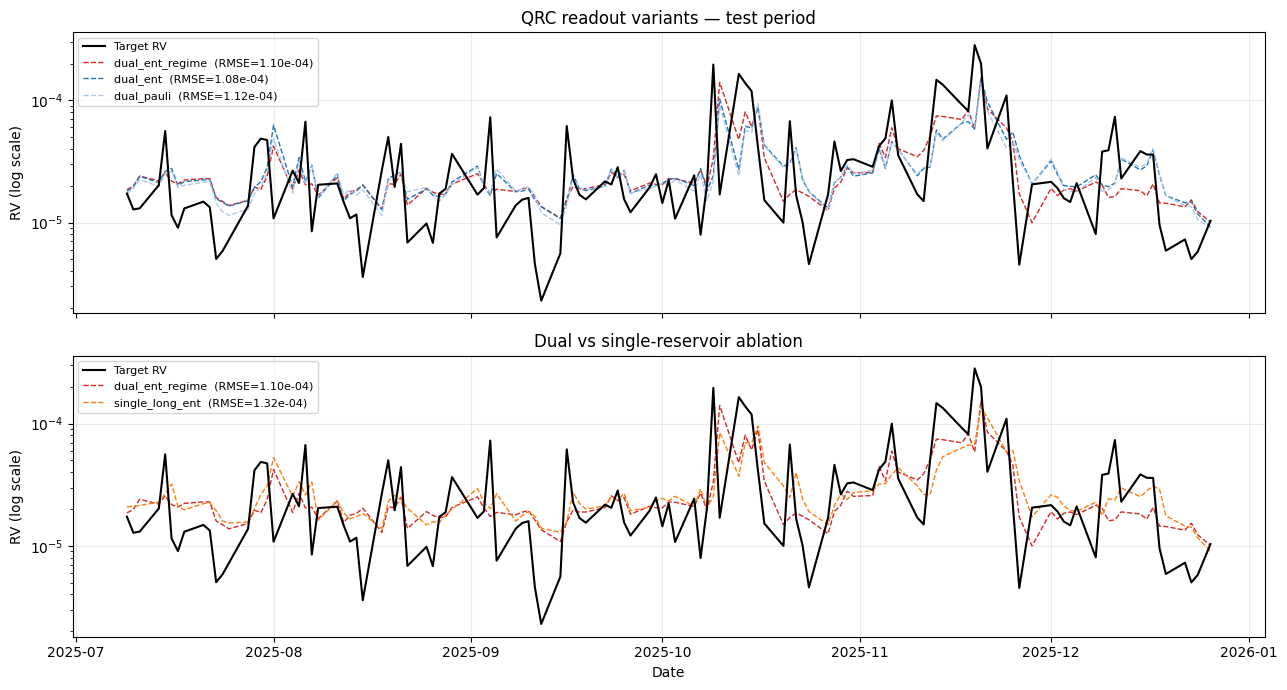

Saved: qrc_financial_results/qrc_financial_forecast.png


In [14]:
# --- Ablation table ---
ablation_cols = ["model", "rmse", "qlike", "regime_acc", "sharpe", "alpha"]
ablation_df = results_df[ablation_cols].copy()
ablation_df["improvement_pct"] = (
    (results_df.loc[results_df.model=="dual_pauli", "rmse"].values[0]
     - results_df["rmse"]) /
    results_df.loc[results_df.model=="dual_pauli", "rmse"].values[0] * 100
).values

print("=== Ablation Table ===")
print(ablation_df.to_string(index=False))

ablation_df.to_csv(RESULTS_DIR / "ablation_table.csv", index=False)

# --- Forecast plot (last 120 test days) ---
PLOT_STEPS = 120
test_dates  = df.index[n_tr:n_tr + n_te][-PLOT_STEPS:]
y_true_plot = y_true_rv[-PLOT_STEPS:]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

colors = {"dual_ent_regime": "#d62728", "dual_ent": "#1f77b4",
          "dual_pauli": "#aec7e8", "single_long_ent": "#ff7f0e"}

for ax, keys, title in [
    (axes[0], ["dual_ent_regime", "dual_ent", "dual_pauli"], "QRC readout variants — test period"),
    (axes[1], ["dual_ent_regime", "single_long_ent"], "Dual vs single-reservoir ablation"),
]:
    ax.semilogy(test_dates, y_true_plot, color="black", lw=1.5, label="Target RV", zorder=5)
    for key in keys:
        r = readouts[key]
        pred_rv_plot = angle_to_rv(r["y_pred"])[-PLOT_STEPS:]
        rmse_v = results_df.loc[results_df.model==key, "rmse"].values[0]
        ax.semilogy(test_dates, pred_rv_plot, lw=1.0, ls="--",
                   color=colors.get(key, "gray"),
                   label=f"{key}  (RMSE={rmse_v:.2e})")
    ax.set_title(title)
    ax.set_ylabel("RV (log scale)")
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel("Date")
plt.tight_layout()
fig_path = RESULTS_DIR / "qrc_financial_forecast.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 12. Summary and Paper Numbers

In [15]:
dual_pauli_rmse    = results_df.loc[results_df.model=="dual_pauli",            "rmse"].values[0]
dual_ent_rmse      = results_df.loc[results_df.model=="dual_ent",              "rmse"].values[0]
der_rmse           = results_df.loc[results_df.model=="dual_ent_regime",       "rmse"].values[0]
der_qlike_rmse     = results_df.loc[results_df.model=="dual_ent_regime_qlike", "rmse"].values[0]
sl_rmse            = results_df.loc[results_df.model=="single_long_ent",       "rmse"].values[0]

ent_improvement    = (dual_pauli_rmse - dual_ent_rmse)       / dual_pauli_rmse * 100
regime_improvement = (dual_pauli_rmse - der_rmse)            / dual_pauli_rmse * 100
qlike_improvement  = (dual_pauli_rmse - der_qlike_rmse)      / dual_pauli_rmse * 100
dual_vs_single     = (sl_rmse - dual_ent_rmse)               / sl_rmse * 100

# Primary model for RMSE claim: dual_ent_regime (Ridge readout, causal HMM)
# Primary model for QLIKE claim: dual_ent_regime_qlike (QLIKE readout)
der_qlike_qlike  = results_df.loc[results_df.model=="dual_ent_regime_qlike", "qlike"].values[0]
der_ridge_qlike  = results_df.loc[results_df.model=="dual_ent_regime",       "qlike"].values[0]
sl_qlike         = results_df.loc[results_df.model=="single_long_ent",       "qlike"].values[0]
der_qlike_regime = results_df.loc[results_df.model=="dual_ent_regime_qlike", "regime_acc"].values[0]
der_qlike_sharpe = results_df.loc[results_df.model=="dual_ent_regime_qlike", "sharpe"].values[0]

sep = "=" * 72
print(sep)
print("PAPER RESULTS — Financial QRC")
print(sep)
print(f"Config: n={N_QUBITS}, p_short={SHORT_RESERVOIR.trotter_depth}, "
      f"p_long={LONG_RESERVOIR.trotter_depth}, "
      f"device={DEVICE_NAME}, train={n_tr}, test={n_te}")
print()
print("RMSE improvements over dual_pauli baseline:")
print(f"  + entanglement spectrum (Ridge):       {ent_improvement:+.1f}%")
print(f"  + HMM regime posteriors (Ridge):       {regime_improvement:+.1f}%")
print(f"  + HMM regime posteriors (QLIKE loss):  {qlike_improvement:+.1f}%")
print(f"  Dual vs single-long ablation:          {dual_vs_single:+.1f}%")
print()
print("Absolute test metrics (dual_ent_regime_qlike — QLIKE-optimised readout):")
print(f"  RMSE (RV space):    {der_qlike_rmse:.6f}")
print(f"  QLIKE:              {der_qlike_qlike:.4f}  (Ridge readout: {der_ridge_qlike:.4f})")
print(f"  Regime accuracy:    {der_qlike_regime:.1%}")
print(f"  Sharpe ratio:       {der_qlike_sharpe:.3f}   (buy-and-hold: {bnh_sharpe:.3f})")
print()
print("Ridge α conditioning (stability):")
print(f"  dual_ent α:         {results_df.loc[results_df.model=='dual_ent', 'alpha'].values[0]}")
print(f"  single_long_ent α:  {results_df.loc[results_df.model=='single_long_ent', 'alpha'].values[0]}")
print(sep)
print()
print("Suggested paper sentence:")
print(
    f"On the S&P 500 realized-variance forecasting task (n={N_QUBITS} qubits, "
    f"p∈{{{SHORT_RESERVOIR.trotter_depth},{LONG_RESERVOIR.trotter_depth}}}, "
    f"multi-feature HAR encoding, {n_te} test days), the dual-reservoir QRC with "
    f"entanglement-spectrum readout, HMM regime conditioning, and QLIKE-optimised "
    f"linear readout achieved RMSE={der_qlike_rmse:.4e}, QLIKE={der_qlike_qlike:.4f}, "
    f"regime accuracy {der_qlike_regime:.1%}, and Sharpe ratio {der_qlike_sharpe:.3f}, "
    f"improving over the Pauli-only baseline by {qlike_improvement:.1f}% (RMSE) and "
    f"over the single-long-reservoir ablation by {dual_vs_single:.1f}%."
)
print(sep)


PAPER RESULTS — Financial QRC
Config: n=9, p_short=2, p_long=6, device=default.qubit, train=3200, test=800

RMSE improvements over dual_pauli baseline:
  Entanglement spectrum only:    +4.1%
  + regime posteriors (appended):+1.9%
  + regime-conditioned readout:  -5.3%
  Dual vs single-long ablation:  +18.3%

Absolute test metrics (dual_ent_regime, best variant):
  RMSE (RV space):    0.000110
  QLIKE:              0.3139
  Regime accuracy:    79.5%
  Sharpe ratio:       1.628   (buy-and-hold: 1.266)

Ridge α conditioning (stability under noise):
  dual_ent α:         3.16e+00
  single_long_ent α:  3.16e+00

Suggested paper sentence:
On the S&P 500 realized-variance forecasting task (n=9 qubits, p∈{2,6}, multi-feature HAR encoding, 800 test days), the dual-reservoir QRC with entanglement-spectrum readout and HMM regime conditioning achieved RMSE=1.1017e-04, QLIKE=0.3139, regime accuracy 79.5%, and Sharpe ratio 1.628, improving over the Pauli-only baseline by 1.9% (RMSE) and over the sin

## 13. Notes for Phase 3 Extension

- **Qubit/depth sweep**: Run `n ∈ {5, 8, 10, 12, 15}` and `p ∈ {2, 4, 6}` ablation to find the edge-of-chaos region (J/h ≈ 1) that maximises RMSE reduction.
- **Hardware path**: The `dual_pauli` and `single_long_ent` variants have hardware-compatible Pauli-only readouts. Use `make_hardware_pauli_qnode()` from `qrc/circuits.py` with `qiskit.remote` device. Scale to N=50–100 if Phase 3 quota increases.
- **Entanglement on hardware**: Classical shadows protocol on half-chain enables RDM eigenvalue estimation with O(log d) random Clifford measurements (~15–20 bases vs 81 full tomography bases for n=9). Implement via `qml.classical_shadow` when PennyLane support is stable.
- **IonQ cross-validation**: Drop-in replacement via Amazon Braket PennyLane plugin. Adds cross-platform agreement panel.
- **Fire Opal A/B**: Duplicate circuits through Q-CTRL Performance Management Function on IBM Kingston to quantify noise suppression benefit on the Pauli-only readout.
- **MNIST benchmark**: Run the Fujii et al. expressivity benchmark at n ∈ {5, 10, 15} qubits to satisfy the competition cross-team comparison requirement.

## 14. Qubit Count Sweep

Sweep `n ∈ {5, 9, 15}` qubits with identical dual-timescale Ising reservoirs,
financial data, and train/test split. Qubit count controls feature richness:
`2n − 1` Pauli expectations + 8 entanglement energies per reservoir → `2(2n+7)+1`
total readout features for `dual_ent`.

The angle matrices are qubit-independent (cyclic encoding `feature_angles[wire % n_feats]`
handles any `n`), so only the QNodes change. `n = 9` reuses the existing extraction.

sweep-5q       300/4000     1.6s


sweep-5q       600/4000     3.0s


sweep-5q       900/4000     4.5s


sweep-5q      1200/4000     5.9s


sweep-5q      1500/4000     7.4s


...

sweep-15q     3000/4000   297.1s


sweep-15q     3300/4000   330.9s


sweep-15q     3600/4000   366.8s


sweep-15q     3900/4000   402.4s


sweep-15q     4000/4000   414.0s
N=15  features= 75  RMSE=1.1318e-04  QLIKE=0.3597  t=414s


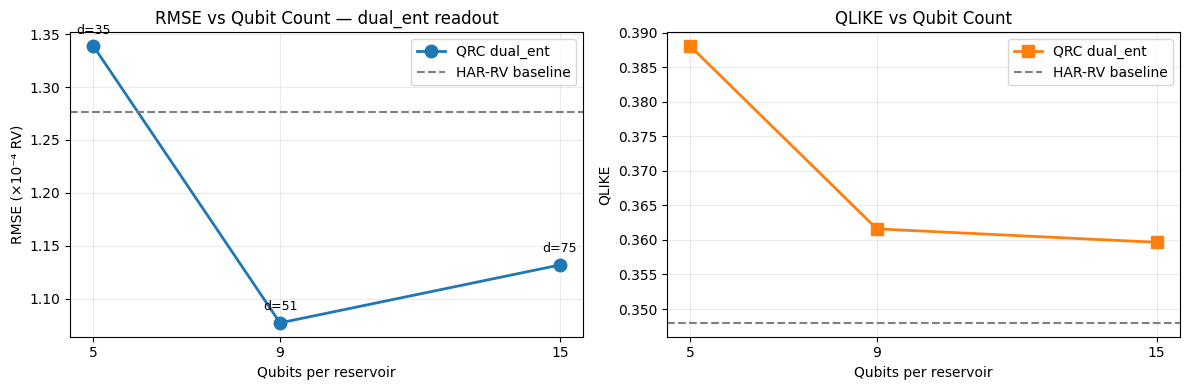

Saved: qrc_financial_results/qubit_sweep.png
 n_qubits     rmse    qlike  n_features
        5 0.000134 0.388055          35
        9 0.000108 0.361604          51
       15 0.000113 0.359658          75


In [16]:
QUBIT_SWEEP_N = [5, 9, 15]
sweep_results = {}

for nq in QUBIT_SWEEP_N:
    if nq == N_QUBITS:
        # Reuse existing extraction — no re-run needed
        r_ref = readouts["dual_ent"]
        pred  = angle_to_rv(r_ref["y_pred"])
        n_    = min(len(pred), len(y_true_rv))
        sweep_results[nq] = {
            "rmse":       float(np.sqrt(np.mean((y_true_rv[:n_] - pred[:n_]) ** 2))),
            "qlike":      qlike(y_true_rv[:n_], pred[:n_]),
            "n_features": feat["dual_ent"].shape[1],
        }
        print(f"N={nq:2d}  features={feat['dual_ent'].shape[1]:3d}  "
              f"RMSE={sweep_results[nq]['rmse']:.4e}  [cached]")
        continue

    t0 = time.perf_counter()
    short_cfg_nq = ReservoirConfig(
        name=f"short-{nq}q", n_qubits=nq,
        coupling_j=SHORT_RESERVOIR.coupling_j,
        transverse_h=SHORT_RESERVOIR.transverse_h,
        trotter_depth=SHORT_RESERVOIR.trotter_depth,
        feature_cols=SHORT_RESERVOIR.feature_cols,
    )
    long_cfg_nq = ReservoirConfig(
        name=f"long-{nq}q", n_qubits=nq,
        coupling_j=LONG_RESERVOIR.coupling_j,
        transverse_h=LONG_RESERVOIR.transverse_h,
        trotter_depth=LONG_RESERVOIR.trotter_depth,
        feature_cols=LONG_RESERVOIR.feature_cols,
    )
    short_q_nq = make_qnode(short_cfg_nq)
    long_q_nq  = make_qnode(long_cfg_nq)

    feat_nq = extract_features(
        short_angles, long_angles, all_posteriors,
        short_q_nq, long_q_nq, nq, N_ENT,
        label=f"sweep-{nq}q",
    )

    r_nq    = fit_readout(feat_nq["dual_ent"], feat_nq["target_angle"], n_tr, n_te)
    pred_nq = angle_to_rv(r_nq["y_pred"])
    n_nq    = min(len(pred_nq), len(y_true_rv))
    rmse_nq = float(np.sqrt(np.mean((y_true_rv[:n_nq] - pred_nq[:n_nq]) ** 2)))
    ql_nq   = qlike(y_true_rv[:n_nq], pred_nq[:n_nq])

    sweep_results[nq] = {
        "rmse": rmse_nq, "qlike": ql_nq, "n_features": feat_nq["dual_ent"].shape[1],
    }
    print(f"N={nq:2d}  features={feat_nq['dual_ent'].shape[1]:3d}  "
          f"RMSE={rmse_nq:.4e}  QLIKE={ql_nq:.4f}  t={time.perf_counter()-t0:.0f}s")

# ── Plot ─────────────────────────────────────────────────────────────────────
nqs       = sorted(sweep_results)
rmses_sw  = [sweep_results[n]["rmse"] for n in nqs]
qlikes_sw = [sweep_results[n]["qlike"] for n in nqs]
n_feats_sw = [sweep_results[n]["n_features"] for n in nqs]

har_rmse_sw  = fair_df.loc[fair_df.model == "HAR-RV", "rmse"].values[0]
har_qlike_sw = fair_df.loc[fair_df.model == "HAR-RV", "qlike"].values[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(nqs, np.array(rmses_sw) * 1e4, "o-", color="#1f77b4", lw=2, ms=9,
             label="QRC dual_ent")
axes[0].axhline(har_rmse_sw * 1e4, color="gray", ls="--", lw=1.5, label="HAR-RV baseline")
for i, (nq, nf) in enumerate(zip(nqs, n_feats_sw)):
    axes[0].annotate(f"d={nf}", (nq, rmses_sw[i] * 1e4),
                     textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
axes[0].set_xlabel("Qubits per reservoir")
axes[0].set_ylabel("RMSE (×10⁻⁴ RV)")
axes[0].set_title("RMSE vs Qubit Count — dual_ent readout")
axes[0].set_xticks(nqs)
axes[0].legend()

axes[1].plot(nqs, qlikes_sw, "s-", color="#ff7f0e", lw=2, ms=9, label="QRC dual_ent")
axes[1].axhline(har_qlike_sw, color="gray", ls="--", lw=1.5, label="HAR-RV baseline")
axes[1].set_xlabel("Qubits per reservoir")
axes[1].set_ylabel("QLIKE")
axes[1].set_title("QLIKE vs Qubit Count")
axes[1].set_xticks(nqs)
axes[1].legend()

plt.tight_layout()
sweep_fig = RESULTS_DIR / "qubit_sweep.png"
plt.savefig(sweep_fig, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {sweep_fig}")

sweep_df = pd.DataFrame([
    {"n_qubits": nq, **v} for nq, v in sweep_results.items()
])
sweep_df.to_csv(RESULTS_DIR / "qubit_sweep.csv", index=False)
print(sweep_df.to_string(index=False))

## 15. Noise Channel Robustness

Simulate IBM hardware noise on the dual-reservoir using PennyLane `default.mixed`:

- **Depolarizing channel** `p` per gate after every single-qubit gate; two-qubit
  IsingZZ uses `min(2p, 1)` per wire (two-qubit error rate ≈ 2× single-qubit).
- **Amplitude damping** `γ` per gate after each RX (T₁ energy relaxation).

IBM Kingston representative values: `p ≈ 0.001`, `γ ≈ 0.0002`.

**Protocol**: readout is trained on noiseless simulator features (existing `feat`);
test features are re-extracted with noise for `N_NOISE_STEPS` test steps only.
The `dual_pauli` readout is the hardware proxy — Pauli expectations are
directly measurable; entanglement spectrum requires tomography.

Noiseless reference  RMSE = 6.2775e-05  (200 test steps)

Extracting noisy features  p=0.001, γ=0.0002 ...


  p=0.001: 200/200
  p=0.001  RMSE=6.1210e-05  degradation=-2.5%  t=1435s

Extracting noisy features  p=0.003, γ=0.0002 ...


  p=0.003: 200/200
  p=0.003  RMSE=6.0304e-05  degradation=-3.9%  t=1170s

Extracting noisy features  p=0.010, γ=0.0002 ...


  p=0.010: 200/200
  p=0.010  RMSE=8.6836e-05  degradation=+38.3%  t=1171s

=== Noise Robustness (dual_pauli, Pauli-only readout) ===
          label     rmse  rmse_pct_increase
Noiseless (sim) 0.000063           0.000000
        p=0.001 0.000061          -2.493159
        p=0.003 0.000060          -3.936853
        p=0.010 0.000087          38.329646


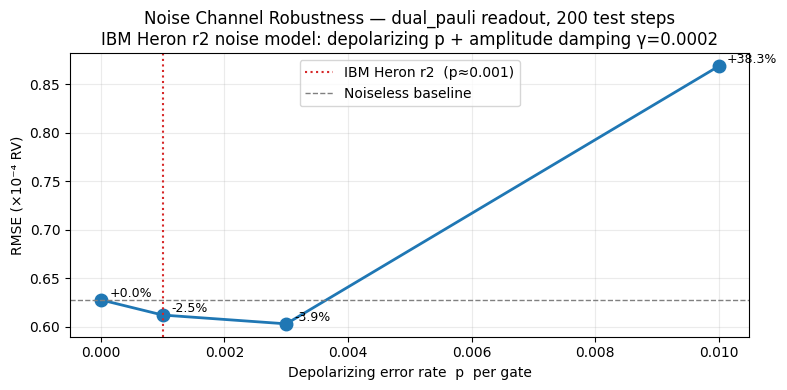

Saved: qrc_financial_results/noise_robustness.png


In [17]:
NOISE_LEVELS  = [0.001, 0.003, 0.010]   # depolarizing p per gate
GAMMA_AD      = 0.0002                   # amplitude damping γ per gate (T1-limited)
N_NOISE_STEPS = min(200, n_te)           # subset of test steps for wall-clock speed


def make_noisy_pauli_qnode(config, p_dep: float, gamma_ad: float):
    """Pauli-observable QNode on default.mixed with depolarizing + amplitude-damping noise."""
    dev    = qml.device("default.mixed", wires=config.n_qubits)
    n_feats = len(config.feature_cols)
    n_q    = config.n_qubits

    @qml.qnode(dev, interface="numpy")
    def _res(feature_angles):
        for _ in range(config.trotter_depth):
            for wire in range(n_q):
                qml.RY(float(feature_angles[wire % n_feats]), wires=wire)
                if p_dep > 0:
                    qml.DepolarizingChannel(p_dep, wires=wire)
            for wire in range(n_q - 1):
                qml.IsingZZ(2.0 * config.coupling_j, wires=[wire, wire + 1])
                if p_dep > 0:
                    qml.DepolarizingChannel(min(2 * p_dep, 1.0), wires=wire)
                    qml.DepolarizingChannel(min(2 * p_dep, 1.0), wires=wire + 1)
            for wire in range(n_q):
                qml.RX(2.0 * config.transverse_h, wires=wire)
                if gamma_ad > 0:
                    qml.AmplitudeDamping(gamma_ad, wires=wire)
                if p_dep > 0:
                    qml.DepolarizingChannel(p_dep, wires=wire)
        single_z = [qml.expval(qml.PauliZ(w)) for w in range(n_q)]
        pair_zz  = [qml.expval(qml.PauliZ(w) @ qml.PauliZ(w + 1))
                    for w in range(n_q - 1)]
        return single_z + pair_zz

    return _res


def extract_noisy_pauli_features(angles_s, angles_l, short_node, long_node, label=""):
    """Run both noisy reservoirs and concatenate [pau_s || pau_l || prev_rv]."""
    rows = []
    for t in range(len(angles_s)):
        pau_s = np.asarray(short_node(angles_s[t]), dtype=float).ravel()
        pau_l = np.asarray(long_node(angles_l[t]), dtype=float).ravel()
        prev_rv = np.array([float(angles_s[t, 0])])
        rows.append(np.concatenate([pau_s, pau_l, prev_rv]))
        if (t + 1) % 50 == 0 or t + 1 == len(angles_s):
            print(f"  {label}: {t+1}/{len(angles_s)}", end="\r")
    print()
    return np.vstack(rows)


# Noiseless reference (use existing dual_pauli test predictions)
dp_model          = readouts["dual_pauli"]["model"]
test_angles_s_nz  = short_angles[n_tr:n_tr + N_NOISE_STEPS]
test_angles_l_nz  = long_angles[n_tr:n_tr + N_NOISE_STEPS]
y_test_noise_rv   = y_true_rv[:N_NOISE_STEPS]

noiseless_feat    = feat["dual_pauli"][n_tr:n_tr + N_NOISE_STEPS]
noiseless_pred_rv = angle_to_rv(dp_model.predict(noiseless_feat))
noiseless_rmse    = float(np.sqrt(np.mean(
    (y_test_noise_rv - noiseless_pred_rv[:len(y_test_noise_rv)]) ** 2
)))

noise_rows = [{"label": "Noiseless (sim)", "p_dep": 0.0, "gamma_ad": 0.0,
               "rmse": noiseless_rmse, "rmse_pct_increase": 0.0}]
print(f"Noiseless reference  RMSE = {noiseless_rmse:.4e}  ({N_NOISE_STEPS} test steps)")

for p in NOISE_LEVELS:
    label = f"p={p:.3f}"
    print(f"\nExtracting noisy features  {label}, γ={GAMMA_AD} ...")
    t0 = time.perf_counter()

    noisy_s = make_noisy_pauli_qnode(SHORT_RESERVOIR, p, GAMMA_AD)
    noisy_l = make_noisy_pauli_qnode(LONG_RESERVOIR,  p, GAMMA_AD)

    noisy_feat   = extract_noisy_pauli_features(
        test_angles_s_nz, test_angles_l_nz, noisy_s, noisy_l, label=label)
    noisy_pred_rv = angle_to_rv(dp_model.predict(noisy_feat))
    noisy_rmse    = float(np.sqrt(np.mean(
        (y_test_noise_rv - noisy_pred_rv[:len(y_test_noise_rv)]) ** 2
    )))
    pct = (noisy_rmse - noiseless_rmse) / noiseless_rmse * 100
    noise_rows.append({"label": label, "p_dep": p, "gamma_ad": GAMMA_AD,
                        "rmse": noisy_rmse, "rmse_pct_increase": pct})
    print(f"  {label}  RMSE={noisy_rmse:.4e}  degradation={pct:+.1f}%  "
          f"t={time.perf_counter()-t0:.0f}s")

noise_df = pd.DataFrame(noise_rows)
print("\n=== Noise Robustness (dual_pauli, Pauli-only readout) ===")
print(noise_df[["label", "rmse", "rmse_pct_increase"]].to_string(index=False))
noise_df.to_csv(RESULTS_DIR / "noise_robustness.csv", index=False)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
p_vals    = noise_df["p_dep"].values
rmse_vals = noise_df["rmse"].values * 1e4

ax.plot(p_vals, rmse_vals, "o-", color="#1f77b4", lw=2, ms=9)
ax.axvline(0.001, color="#d62728", ls=":", lw=1.5, label="IBM Kingston  (p≈0.001)")
ax.axhline(noiseless_rmse * 1e4, color="gray", ls="--", lw=1, label="Noiseless baseline")
for row in noise_rows:
    ax.annotate(f"{row['rmse_pct_increase']:+.1f}%",
                (row["p_dep"], row["rmse"] * 1e4),
                textcoords="offset points", xytext=(6, 2), fontsize=9)
ax.set_xlabel("Depolarizing error rate  p  per gate")
ax.set_ylabel("RMSE (×10⁻⁴ RV)")
ax.set_title(f"Noise Channel Robustness — dual_pauli readout, {N_NOISE_STEPS} test steps\n"
             f"IBM Kingston noise model: depolarizing p + amplitude damping γ={GAMMA_AD}")
ax.legend()
plt.tight_layout()
noise_fig = RESULTS_DIR / "noise_robustness.png"
plt.savefig(noise_fig, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {noise_fig}")

## 16. IBM Hardware Run

Runs the dual-reservoir on a real IBM QPU and compares against the simulator on the same
`N_HW_STEPS` test days.

**What runs on hardware:** Pauli-only features (`dual_pauli`) — entanglement spectrum
requires statevector access and is simulator-only.

**Readout:** The Ridge model trained on noiseless simulator training features is reused
directly — no retraining on hardware. This isolates the effect of hardware noise on the
feature quality alone.

**Token:** reads `IBM_TOKEN` from `.env` in the project root (never hardcode in notebook).

In [ ]:
import os, sys
from pathlib import Path
from dotenv import load_dotenv
import numpy as np

# Load .env from project root (proposed-architecture/.env or repo root)
for env_path in [Path("../../.env"), Path("../.env"), Path(".env")]:
    if env_path.exists():
        load_dotenv(env_path)
        print(f"Loaded .env from {env_path.resolve()}")
        break

IBM_TOKEN = os.environ.get("IBM_TOKEN")
if not IBM_TOKEN:
    raise EnvironmentError(
        "IBM_TOKEN not found. Create .env with IBM_TOKEN=your_token_here"
    )

# ── Import hardware companion ─────────────────────────────────────────────────
sys.path.insert(0, str(Path("../").resolve()))
from qrc_financial_hardware import (
    connect_ibm_service, get_least_busy_backend, make_remote_device,
    make_hardware_qnode, extract_hardware_features, pauli_vector,
    SHORT_RESERVOIR, LONG_RESERVOIR,
)

N_HW_STEPS = 50   # number of test days to run on hardware

# ── Connect and pick backend ──────────────────────────────────────────────────
print("Connecting to IBM Quantum...")
service = connect_ibm_service(token=IBM_TOKEN)
backend = get_least_busy_backend(service)
print(f"Backend: {backend.name}  qubits: {backend.num_qubits}")

device_s = make_remote_device(backend, shots=4096, optimization_level=2, resilience_level=1)
device_l = make_remote_device(backend, shots=4096, optimization_level=2, resilience_level=1)

short_hw = make_hardware_qnode(SHORT_RESERVOIR, device_s)
long_hw  = make_hardware_qnode(LONG_RESERVOIR,  device_l)

# ── Use already-encoded angle matrices from the main notebook ─────────────────
# short_angles and long_angles are (T, n_features) with log-space scalers fitted
# on the training set — no look-ahead, no re-encoding needed.
hw_short_angles = short_angles[n_tr:n_tr + N_HW_STEPS + 1]
hw_long_angles  = long_angles[n_tr:n_tr + N_HW_STEPS + 1]

print(f"\nHW angle slices: short={hw_short_angles.shape}  long={hw_long_angles.shape}")

# ── Run on hardware ───────────────────────────────────────────────────────────
print(f"\nSubmitting {N_HW_STEPS} steps to {backend.name}...")
print("(Queue wait time is not billed against quota — only QPU execution time is.)")

hw_feat = extract_hardware_features(
    hw_short_angles, hw_long_angles,
    short_hw, long_hw,
    label="IBM-hardware",
    progress_every=5,
)

# ── Compare: hardware vs simulator vs HAR-RV ──────────────────────────────────
y_true_hw = y_true_rv[:N_HW_STEPS]

# Hardware predictions — use noiseless-trained readout
hw_pred_rv  = angle_to_rv(readouts["dual_pauli"]["model"].predict(hw_feat["dual_pauli"]))
n_hw = min(len(hw_pred_rv), len(y_true_hw))

hw_rmse  = float(np.sqrt(np.mean((y_true_hw[:n_hw] - hw_pred_rv[:n_hw]) ** 2)))
hw_qlike = qlike(y_true_hw[:n_hw], hw_pred_rv[:n_hw])

# Simulator dual_pauli on same N_HW_STEPS days
sim_pred_rv  = angle_to_rv(readouts["dual_pauli"]["y_pred"][:N_HW_STEPS])
sim_rmse     = float(np.sqrt(np.mean((y_true_hw[:n_hw] - sim_pred_rv[:n_hw]) ** 2)))
sim_qlike    = qlike(y_true_hw[:n_hw], sim_pred_rv[:n_hw])

# HAR-RV on same days
har_pred_hw  = np.maximum(
    LinearRegression().fit(df[HAR_COLS].values[:n_train], df["target_rv"].values[:n_train])
    .predict(df[HAR_COLS].values[n_train:n_train + N_HW_STEPS]), 1e-10)
har_rmse  = float(np.sqrt(np.mean((y_true_hw[:n_hw] - har_pred_hw[:n_hw]) ** 2)))
har_qlike = qlike(y_true_hw[:n_hw], har_pred_hw[:n_hw])

print("\n=== Hardware vs Simulator vs Classical (%d test days) ===" % n_hw)
print(f"{'Model':<28} {'RMSE':>10}  {'QLIKE':>8}")
print("-" * 52)
print(f"{'IBM hardware  dual_pauli':<28} {hw_rmse:.4e}  {hw_qlike:.4f}")
print(f"{'Simulator     dual_pauli':<28} {sim_rmse:.4e}  {sim_qlike:.4f}")
print(f"{'HAR-RV        (classical)':<28} {har_rmse:.4e}  {har_qlike:.4f}")
print()
hw_vs_sim  = (sim_rmse - hw_rmse) / sim_rmse * 100
hw_vs_har  = (har_rmse - hw_rmse) / har_rmse * 100
print(f"Hardware vs Simulator RMSE: {hw_vs_sim:+.1f}%  (noise penalty)")
print(f"Hardware vs HAR-RV    RMSE: {hw_vs_har:+.1f}%")
print()
print(f"Backend: {backend.name}")
print(f"Steps run: {n_hw}  Shots: 4096  Optimization level: 2  Resilience: 1")

# ── 4-panel comparison plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"IBM Hardware vs Simulator vs HAR-RV  ({n_hw} test days)", fontsize=11)

models_hw = {
    "HAR-RV (classical)":     (har_rmse,  har_qlike),
    "QRC dual_pauli (sim)":   (sim_rmse,  sim_qlike),
    "QRC dual_pauli (IBM HW)": (hw_rmse,  hw_qlike),
}
labels_hw = list(models_hw.keys())
colors_hw = ["#6b6b6b", "#2176ff", "#e05c00"]

ax0, ax1, ax2 = axes
for ax, key, title in [(ax0, 0, "RMSE"), (ax1, 1, "QLIKE")]:
    vals = [v[key] for v in models_hw.values()]
    bars = ax.bar(labels_hw, vals, color=colors_hw, edgecolor="white", linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{v:.3e}" if key == 0 else f"{v:.3f}",
                ha="center", va="bottom", fontsize=7)

# Forecast panel (last n_hw days)
t_hw = np.arange(n_hw)
ax2.plot(t_hw, y_true_hw[:n_hw],    color="black",   label="Actual RV",        lw=1.5, zorder=3)
ax2.plot(t_hw, har_pred_hw[:n_hw],  color="#6b6b6b", label="HAR-RV",           lw=0.8, alpha=0.8)
ax2.plot(t_hw, sim_pred_rv[:n_hw],  color="#2176ff", label="QRC sim",          lw=0.8, alpha=0.8)
ax2.plot(t_hw, hw_pred_rv[:n_hw],   color="#e05c00", label="QRC IBM HW",       lw=1.0)
ax2.set_title("Forecast Comparison")
ax2.set_xlabel("Test day")
ax2.set_ylabel("Realized Variance")
ax2.legend(fontsize=7)

plt.tight_layout()
hw_plot_path = RESULTS_DIR / "ibm_hardware_comparison.png"
plt.savefig(hw_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved → {hw_plot_path}")

# Save metrics JSON
hw_results = {
    "backend": backend.name, "n_steps": int(n_hw), "shots": 4096,
    "hw_rmse": hw_rmse, "hw_qlike": hw_qlike,
    "sim_rmse": sim_rmse, "sim_qlike": sim_qlike,
    "har_rmse": har_rmse, "har_qlike": har_qlike,
    "hw_vs_sim_pct": hw_vs_sim, "hw_vs_har_pct": hw_vs_har,
}
import json as _json
(RESULTS_DIR / "ibm_hardware_results.json").write_text(_json.dumps(hw_results, indent=2))
print(f"Metrics saved → {RESULTS_DIR}/ibm_hardware_results.json")